In [2]:
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Data Preprocessing

In [3]:
library(dplyr)

# 讀取原始資料
df <- read.csv("ai_student_impact_dataset.csv", stringsAsFactors = FALSE)

# 檢視初始檔案狀態與資料維度
cat("=== 初始資料狀態 ===\n")
print(dim(df))

# 缺失值與空值檢查
cat("\n=== 檢查缺失值與空字串數量 ===\n")
print(colSums(is.na(df)))
print(colSums(df == "", na.rm = TRUE))

# 刪除無效特徵 Student_ID
df_cleaned <- df[, !(names(df) %in% c("Student_ID"))]

# 檢視處理後的欄位狀態
cat("\n=== 確認刪除 Student_ID 後的欄位清單 ===\n")
print(dim(df_cleaned))
print(colnames(df_cleaned))

# 特徵工程 - 建立派生變數 (GPA_Change, Total_Study_Hours, AI_Time_Ratio)
df_features <- df_cleaned %>%
  mutate(
    GPA_Change = Post_Semester_GPA - Pre_Semester_GPA,
    Total_Study_Hours = Weekly_GenAI_Hours + Traditional_Study_Hours,
    AI_Time_Ratio = ifelse(Total_Study_Hours == 0, 0, Weekly_GenAI_Hours / Total_Study_Hours)
  )

# 檢視新建立之派生欄位數值狀態
cat("\n=== 檢視新欄位前五筆資料 ===\n")
print(head(df_features[, c("GPA_Change", "Total_Study_Hours", "AI_Time_Ratio")], 5))

# 類別變數編碼 (布林轉二元數值、年級與技能與倦怠轉有序因子、科系與情境與政策轉名目因子)
df_final <- df_features %>%
  mutate(
    Paid_Subscription = as.numeric(as.logical(Paid_Subscription)),
    Year_of_Study = factor(Year_of_Study, levels = c("Freshman", "Sophomore", "Junior", "Senior", "Graduate"), ordered = TRUE),
    Prompt_Engineering_Skill = factor(Prompt_Engineering_Skill, levels = c("Beginner", "Intermediate", "Advanced"), ordered = TRUE),
    Burnout_Risk_Level = factor(Burnout_Risk_Level, levels = c("Low", "Medium", "High"), ordered = TRUE),
    Major_Category = factor(Major_Category),
    Primary_Use_Case = factor(Primary_Use_Case),
    Institutional_Policy = factor(Institutional_Policy)
  )

# 檢視最終編碼與資料結構型態
cat("\n=== 驗證最終資料型態與因子設定 ===\n")
str(df_final)

# 輸出最終 CSV 與 RDS 檔案
write.csv(df_final, "ai_student_impact_dataset_final.csv", row.names = FALSE)
saveRDS(df_final, "ai_student_impact_dataset_final.rds")


=== 初始資料狀態 ===
[1] 50000    16

=== 步驟一：檢查缺失值與空字串數量 ===
                Student_ID             Major_Category 
                         0                          0 
             Year_of_Study           Pre_Semester_GPA 
                         0                          0 
        Weekly_GenAI_Hours           Primary_Use_Case 
                         0                          0 
  Prompt_Engineering_Skill             Tool_Diversity 
                         0                          0 
         Paid_Subscription    Traditional_Study_Hours 
                         0                          0 
   Perceived_AI_Dependency       Institutional_Policy 
                         0                          0 
Anxiety_Level_During_Exams          Post_Semester_GPA 
                         0                          0 
     Skill_Retention_Score         Burnout_Risk_Level 
                         0                          0 
                Student_ID             Major_Category 
         

In [4]:
df <- readRDS("ai_student_impact_dataset_final.rds")

# 確認每一個欄位的缺失值總數
colSums(is.na(df))
# 檢查各變數的最小值、最大值與四分位數
summary(df)
# 檢視資料結構與變數型態
str(df)

Major_Category              Year_of_Study 
                         0                          0 
          Pre_Semester_GPA         Weekly_GenAI_Hours 
                         0                          0 
          Primary_Use_Case   Prompt_Engineering_Skill 
                         0                          0 
            Tool_Diversity          Paid_Subscription 
                         0                          0 
   Traditional_Study_Hours    Perceived_AI_Dependency 
                         0                          0 
      Institutional_Policy Anxiety_Level_During_Exams 
                         0                          0 
         Post_Semester_GPA      Skill_Retention_Score 
                         0                          0 
        Burnout_Risk_Level                 GPA_Change 
                         0                          0 
         Total_Study_Hours              AI_Time_Ratio 
                         0                          0

    Major_Category    Year_of_Study   Pre_Semester_GPA Weekly_GenAI_Hours
 Arts      : 5933   Freshman :11031   Min.   :1.183    Min.   : 0.000    
 Business  :12538   Sophomore: 9860   1st Qu.:2.834    1st Qu.: 2.390    
 Humanities: 9994   Junior   :11045   Median :3.210    Median : 5.800    
 Medical   : 6476   Senior   :10634   Mean   :3.146    Mean   : 8.428    
 STEM      :15059   Graduate : 7430   3rd Qu.:3.521    3rd Qu.:11.720    
                                      Max.   :3.998    Max.   :40.000    
                  Primary_Use_Case Prompt_Engineering_Skill Tool_Diversity
 Copywriting/Drafting     :12011   Beginner    :18495       Min.   :1.0   
 Debugging/Troubleshooting:12295   Intermediate:17696       1st Qu.:2.0   
 Direct_Answer_Generation : 6340   Advanced    :13809       Median :3.0   
 Ideation                 :10721                            Mean   :2.8   
 Summarizing_Reading      : 8633                            3rd Qu.:4.0   
                                

'data.frame':	50000 obs. of  18 variables:
 $ Major_Category            : Factor w/ 5 levels "Arts","Business",..: 3 4 2 2 5 5 5 1 2 2 ...
 $ Year_of_Study             : Ord.factor w/ 5 levels "Freshman"<"Sophomore"<..: 4 3 1 4 2 3 1 3 2 2 ...
 $ Pre_Semester_GPA          : num  2.42 3.82 3.4 3.79 3.63 ...
 $ Weekly_GenAI_Hours        : num  23.31 1.12 21.26 1.82 9.29 ...
 $ Primary_Use_Case          : Factor w/ 5 levels "Copywriting/Drafting",..: 1 4 5 1 2 2 5 1 2 2 ...
 $ Prompt_Engineering_Skill  : Ord.factor w/ 3 levels "Beginner"<"Intermediate"<..: 1 3 1 2 3 1 3 2 1 2 ...
 $ Tool_Diversity            : int  1 5 2 4 4 1 5 3 2 2 ...
 $ Paid_Subscription         : num  1 0 0 0 0 0 1 0 1 1 ...
 $ Traditional_Study_Hours   : num  8.13 16.65 10.35 15.23 12.55 ...
 $ Perceived_AI_Dependency   : int  5 3 5 2 4 4 8 2 1 3 ...
 $ Institutional_Policy      : Factor w/ 3 levels "Actively_Encouraged",..: 2 2 3 2 2 2 2 1 3 3 ...
 $ Anxiety_Level_During_Exams: int  6 9 9 2 4 5 7 1 5 8 ...
 $ Post

## Exploratory Data Analysis

In [5]:
# Install packages if needed
install.packages(c("tidyverse", "skimr", "janitor", "GGally", "corrplot"))

# Load packages
library(tidyverse)
library(skimr)
library(janitor)
library(GGally)
library(corrplot)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ ggplot2   4.0.3     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test


corrplot 0.95 loaded



In [6]:
# Load processed dataset
df <- read_csv("ai_student_impact_dataset_final.csv")

# Basic dataset overview
dim(df)
glimpse(df)
head(df)

Rows: 50000 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): Major_Category, Year_of_Study, Primary_Use_Case, Prompt_Engineerin...
dbl (12): Pre_Semester_GPA, Weekly_GenAI_Hours, Tool_Diversity, Paid_Subscri...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 50000    18

Rows: 50,000
Columns: 18
$ Major_Category             <chr> "Humanities", "Medical", "Business", "Busin…
$ Year_of_Study              <chr> "Senior", "Junior", "Freshman", "Senior", "…
$ Pre_Semester_GPA           <dbl> 2.418, 3.821, 3.398, 3.789, 3.635, 3.449, 3…
$ Weekly_GenAI_Hours         <dbl> 23.31, 1.12, 21.26, 1.82, 9.29, 6.50, 31.41…
$ Primary_Use_Case           <chr> "Copywriting/Drafting", "Ideation", "Summar…
$ Prompt_Engineering_Skill   <chr> "Beginner", "Advanced", "Beginner", "Interm…
$ Tool_Diversity             <dbl> 1, 5, 2, 4, 4, 1, 5, 3, 2, 2, 3, 3, 2, 1, 1…
$ Paid_Subscription          <dbl> 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0…
$ Traditional_Study_Hours    <dbl> 8.13, 16.65, 10.35, 15.23, 12.55, 14.19, 13…
$ Perceived_AI_Dependency    <dbl> 5, 3, 5, 2, 4, 4, 8, 2, 1, 3, 5, 3, 2, 2, 2…
$ Institutional_Policy       <chr> "Allowed_With_Citation", "Allowed_With_Cita…
$ Anxiety_Level_During_Exams <dbl> 6, 9, 9, 2, 4, 5, 7, 1, 5, 8, 3, 3, 4, 3, 4…
$ Post_Semester

Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change,Total_Study_Hours,AI_Time_Ratio
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025,31.44,0.74141221
Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125,17.77,0.06302757
Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101,31.61,0.67257197
Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211,17.05,0.10674487
STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163,21.84,0.42536630
STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,0,14.19,4,Allowed_With_Citation,5,3.666,65.92,High,0.217,20.69,0.31416143


In [7]:
# Check missing values and duplicate rows
colSums(is.na(df))
sum(duplicated(df))

Major_Category              Year_of_Study 
                         0                          0 
          Pre_Semester_GPA         Weekly_GenAI_Hours 
                         0                          0 
          Primary_Use_Case   Prompt_Engineering_Skill 
                         0                          0 
            Tool_Diversity          Paid_Subscription 
                         0                          0 
   Traditional_Study_Hours    Perceived_AI_Dependency 
                         0                          0 
      Institutional_Policy Anxiety_Level_During_Exams 
                         0                          0 
         Post_Semester_GPA      Skill_Retention_Score 
                         0                          0 
        Burnout_Risk_Level                 GPA_Change 
                         0                          0 
         Total_Study_Hours              AI_Time_Ratio 
                         0                          0

[1] 0

In [8]:
# Summary statistics for numeric variables
numeric_summary <- df %>%
  select(where(is.numeric)) %>%
  summary()

numeric_summary

 Pre_Semester_GPA Weekly_GenAI_Hours Tool_Diversity Paid_Subscription
 Min.   :1.183    Min.   : 0.000     Min.   :1.0    Min.   :0.0000   
 1st Qu.:2.834    1st Qu.: 2.390     1st Qu.:2.0    1st Qu.:0.0000   
 Median :3.210    Median : 5.800     Median :3.0    Median :0.0000   
 Mean   :3.146    Mean   : 8.428     Mean   :2.8    Mean   :0.4231   
 3rd Qu.:3.521    3rd Qu.:11.720     3rd Qu.:4.0    3rd Qu.:1.0000   
 Max.   :3.998    Max.   :40.000     Max.   :5.0    Max.   :1.0000   
 Traditional_Study_Hours Perceived_AI_Dependency Anxiety_Level_During_Exams
 Min.   : 1.00           Min.   : 1.000          Min.   : 1.000            
 1st Qu.: 7.56           1st Qu.: 2.000          1st Qu.: 3.000            
 Median :11.18           Median : 3.000          Median : 4.000            
 Mean   :11.21           Mean   : 3.505          Mean   : 4.271            
 3rd Qu.:14.71           3rd Qu.: 5.000          3rd Qu.: 6.000            
 Max.   :35.86           Max.   :10.000          Max. 

In [9]:
# Frequency and proportion tables for categorical variables

categorical_vars <- df %>%
  select(where(is.character)) %>%
  names()

categorical_vars

for (var in categorical_vars) {
  cat("\n====================\n")
  cat(var, "\n")

  freq_table <- df %>%
    count(.data[[var]]) %>%
    mutate(percentage = n / sum(n) * 100) %>%
    arrange(desc(n))

  print(freq_table)
}

[1] "Major_Category"           "Year_of_Study"           
[3] "Primary_Use_Case"         "Prompt_Engineering_Skill"
[5] "Institutional_Policy"     "Burnout_Risk_Level"


Major_Category 
# A tibble: 5 × 3
  Major_Category     n percentage
  <chr>          <int>      <dbl>
1 STEM           15059       30.1
2 Business       12538       25.1
3 Humanities      9994       20.0
4 Medical         6476       13.0
5 Arts            5933       11.9

Year_of_Study 
# A tibble: 5 × 3
  Year_of_Study     n percentage
  <chr>         <int>      <dbl>
1 Junior        11045       22.1
2 Freshman      11031       22.1
3 Senior        10634       21.3
4 Sophomore      9860       19.7
5 Graduate       7430       14.9

Primary_Use_Case 
# A tibble: 5 × 3
  Primary_Use_Case              n percentage
  <chr>                     <int>      <dbl>
1 Debugging/Troubleshooting 12295       24.6
2 Copywriting/Drafting      12011       24.0
3 Ideation                  10721       21.4
4 Summarizing_Reading        8633       17.3
5 Direct_Answer_Generation   6340       12.7

Prompt_Engineering_Skill 
# A tibble: 3 × 3
  Prompt_Engineering_Skill     n percentage
  <chr>              

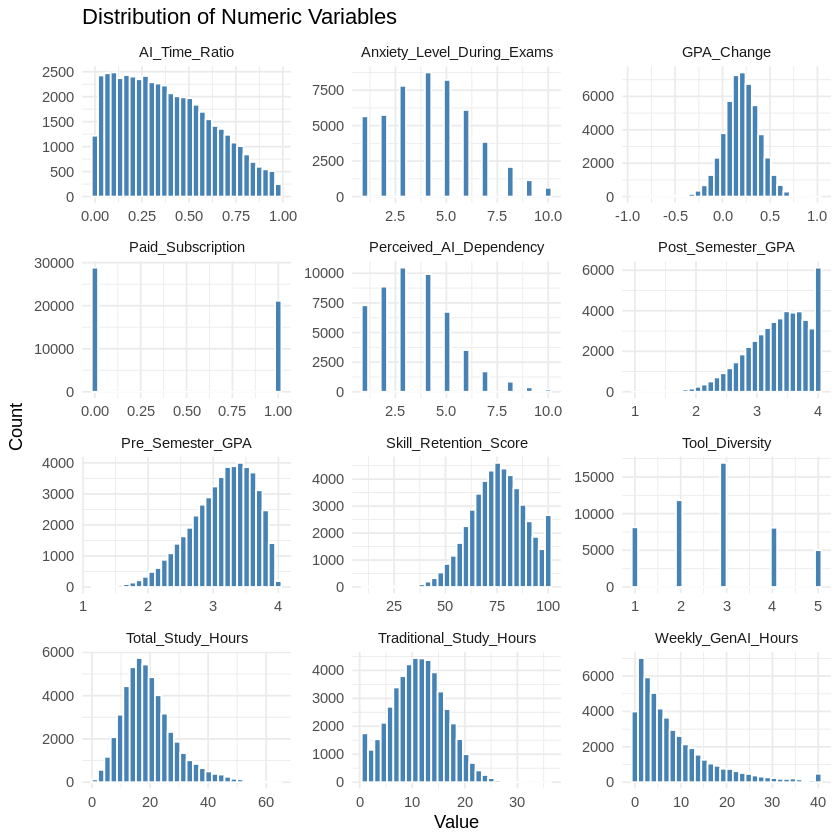

In [10]:
numeric_vars <- df %>%
  select(where(is.numeric)) %>%
  names()

df %>%
  select(all_of(numeric_vars)) %>%
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") %>%
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~ variable, scales = "free", ncol = 3) +
  theme_minimal() +
  labs(
    title = "Distribution of Numeric Variables",
    x = "Value",
    y = "Count"
  )

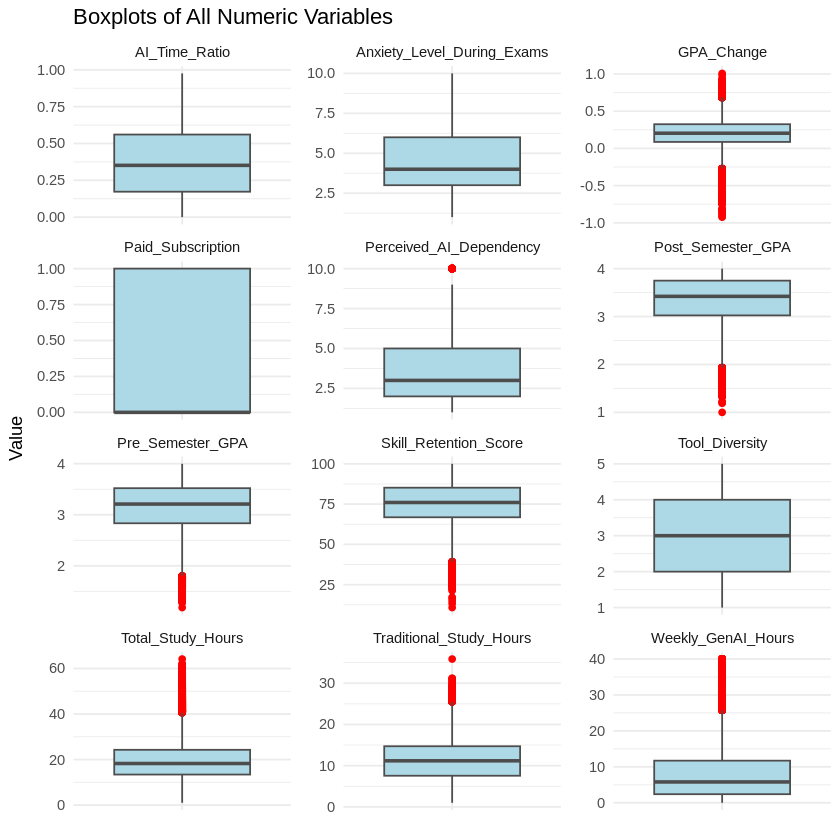

In [11]:
# Boxplots for all numeric variables

df %>%
  select(all_of(numeric_vars)) %>%
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") %>%
  ggplot(aes(x = variable, y = value)) +
  geom_boxplot(fill = "lightblue", color = "gray30", outlier.color = "red") +
  facet_wrap(~ variable, scales = "free", ncol = 3) +
  theme_minimal() +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
  labs(
    title = "Boxplots of All Numeric Variables",
    x = "",
    y = "Value"
  )

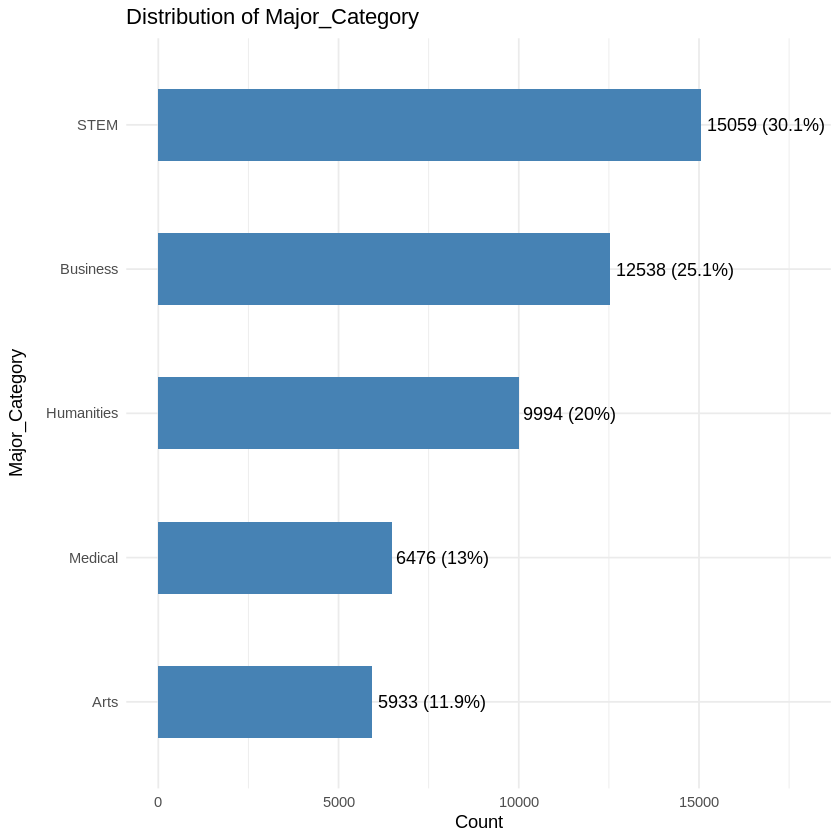

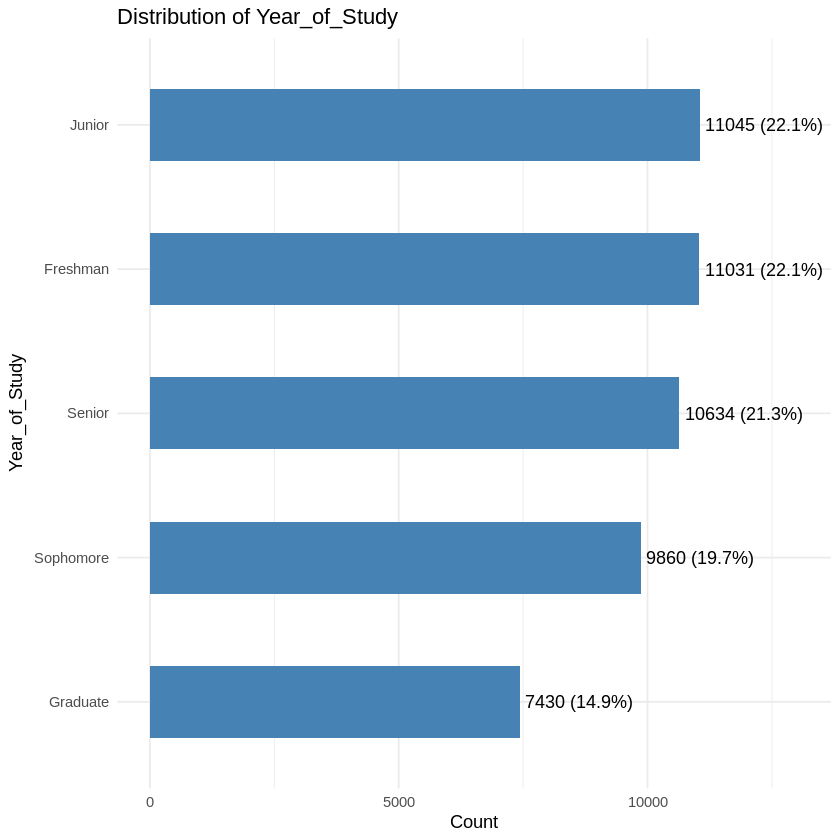

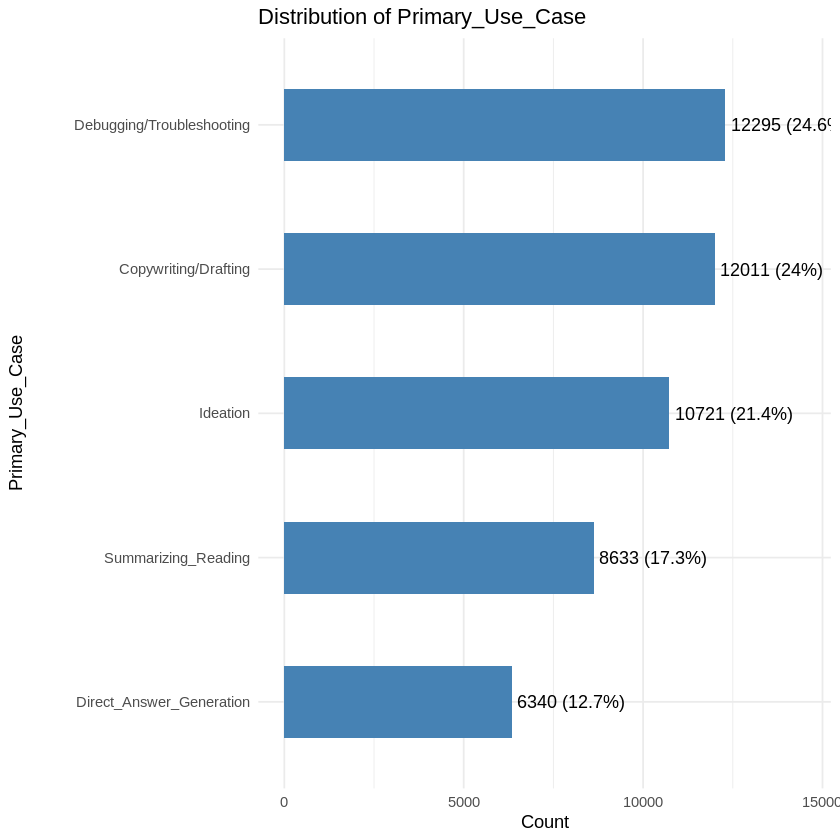

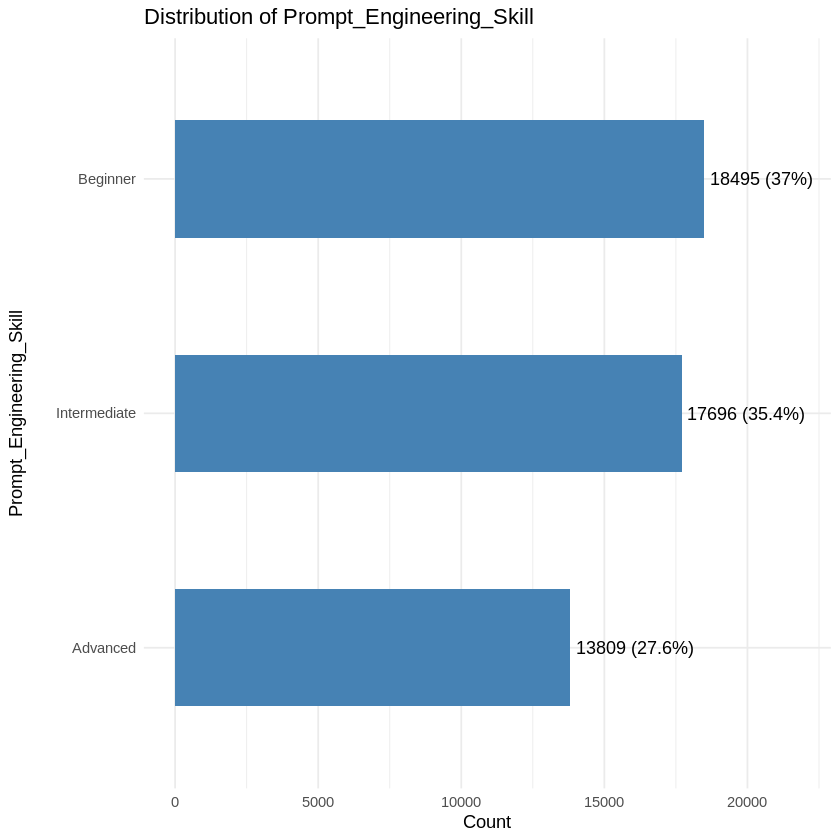

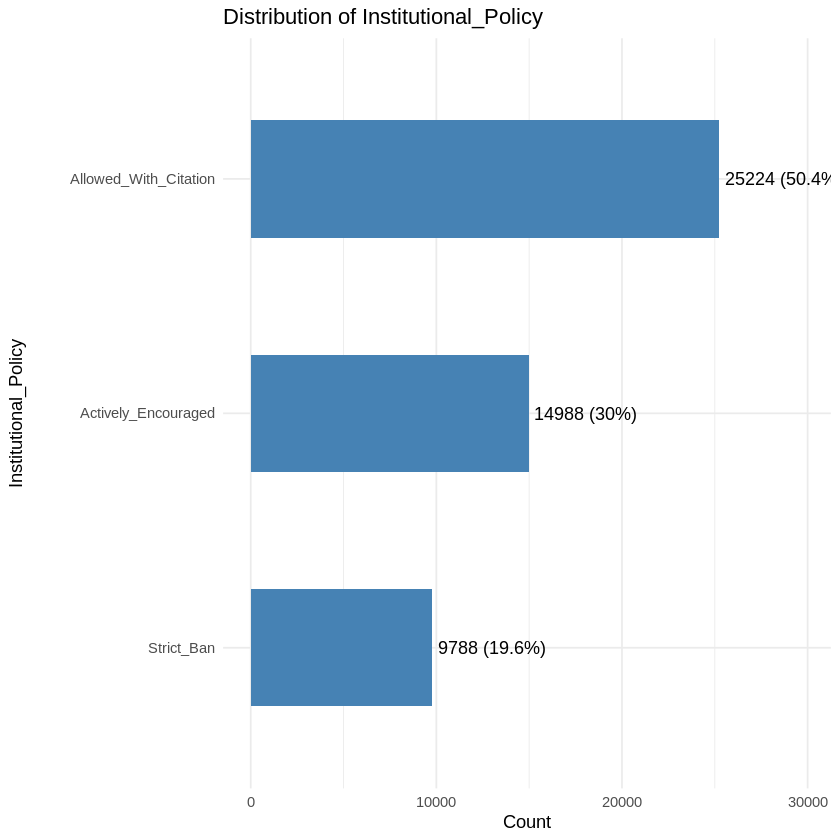

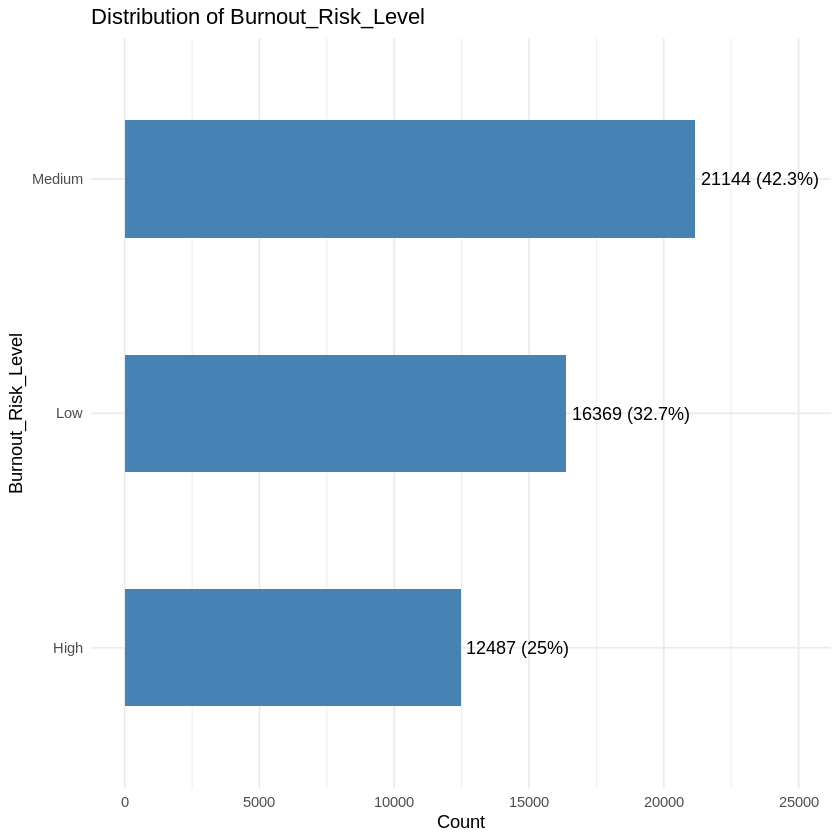

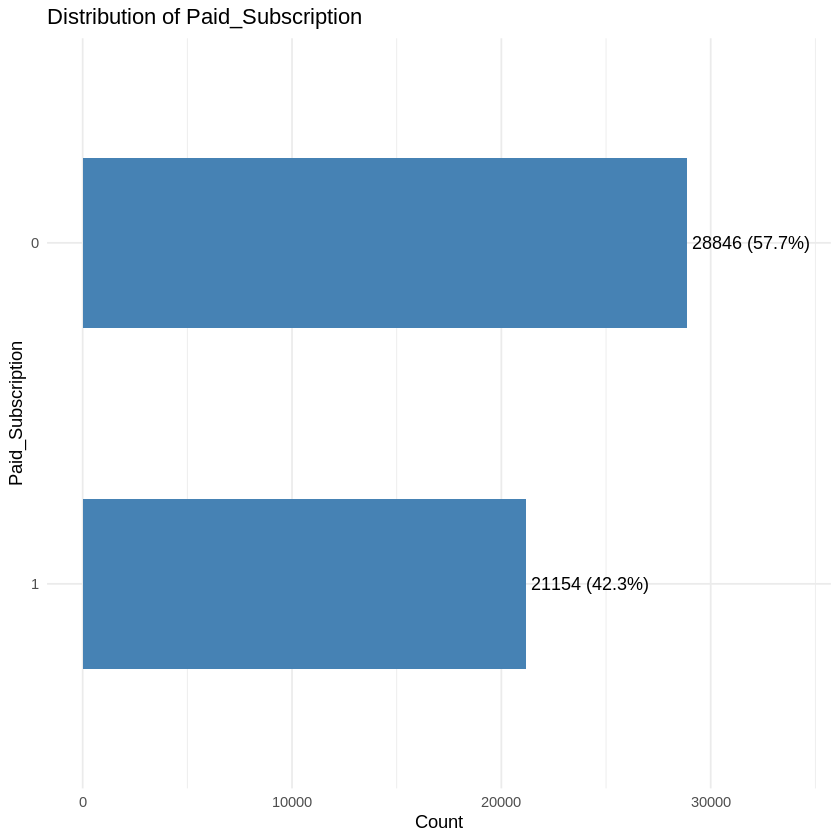

In [12]:
# Better bar charts with thinner bars

categorical_vars <- c(
  df %>% select(where(is.character)) %>% names(),
  "Paid_Subscription"
)

for (var in categorical_vars) {

  plot_data <- df %>%
    count(.data[[var]]) %>%
    mutate(
      percentage = n / sum(n) * 100,
      label = paste0(n, " (", round(percentage, 1), "%)")
    ) %>%
    arrange(n)

  p <- ggplot(plot_data, aes(x = reorder(as.factor(.data[[var]]), n), y = n)) +
    geom_col(fill = "steelblue", width = 0.5) +
    geom_text(aes(label = label), hjust = -0.05, size = 3.8) +
    coord_flip() +
    theme_minimal() +
    labs(
      title = paste("Distribution of", var),
      x = var,
      y = "Count"
    ) +
    expand_limits(y = max(plot_data$n) * 1.18)

  print(p)
}

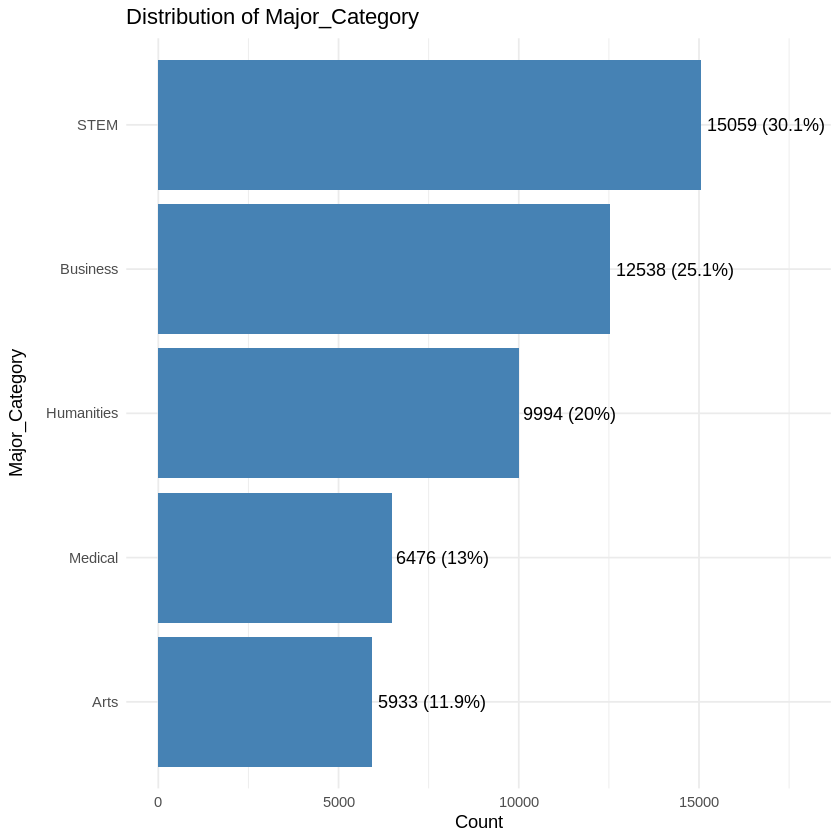

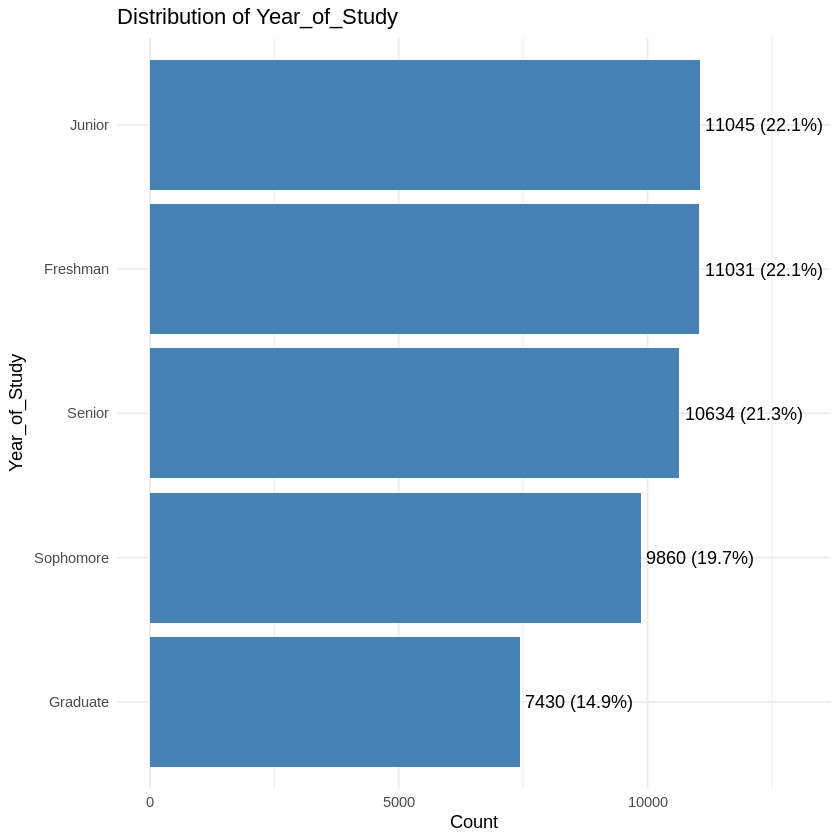

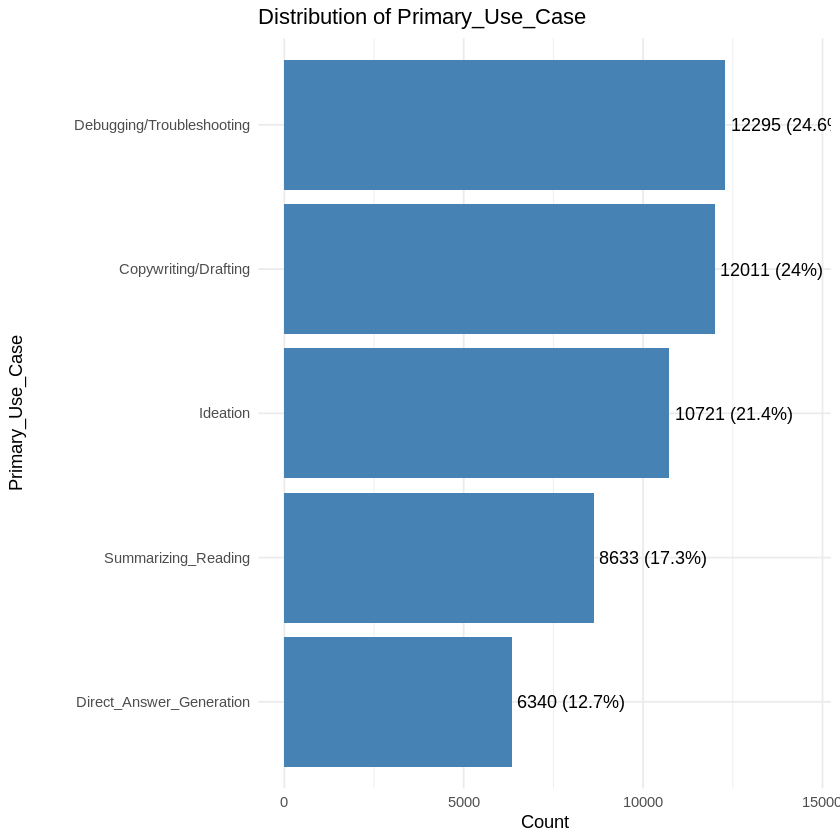

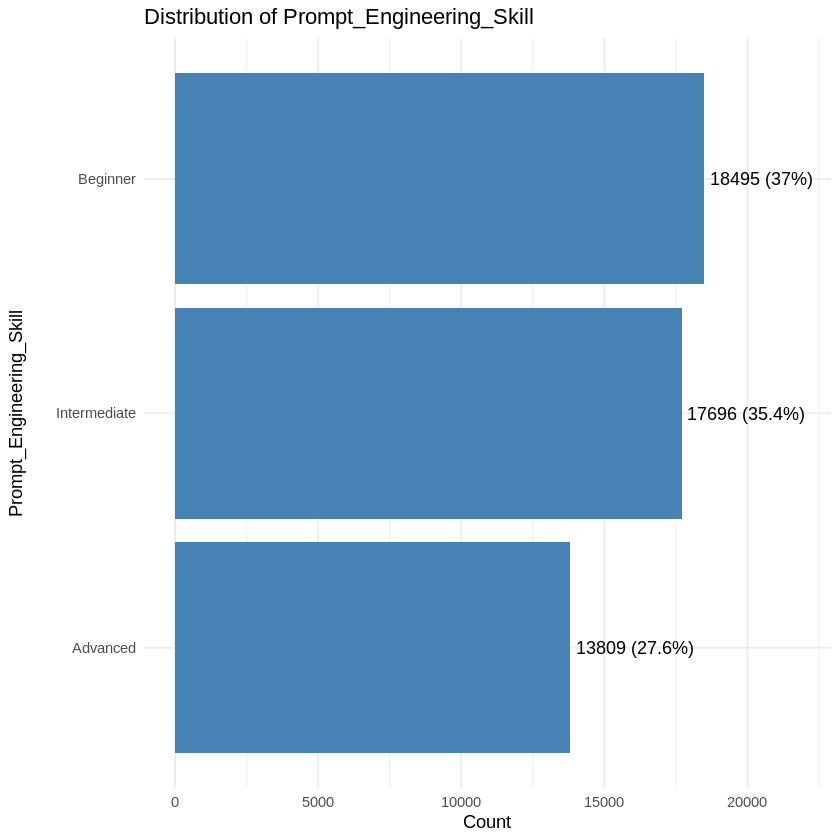

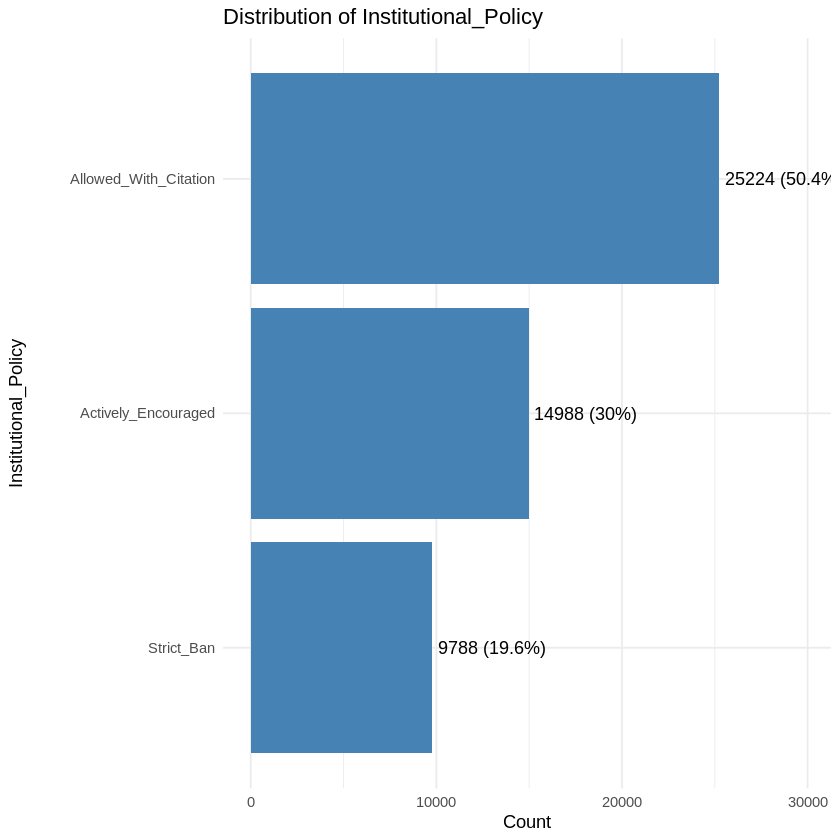

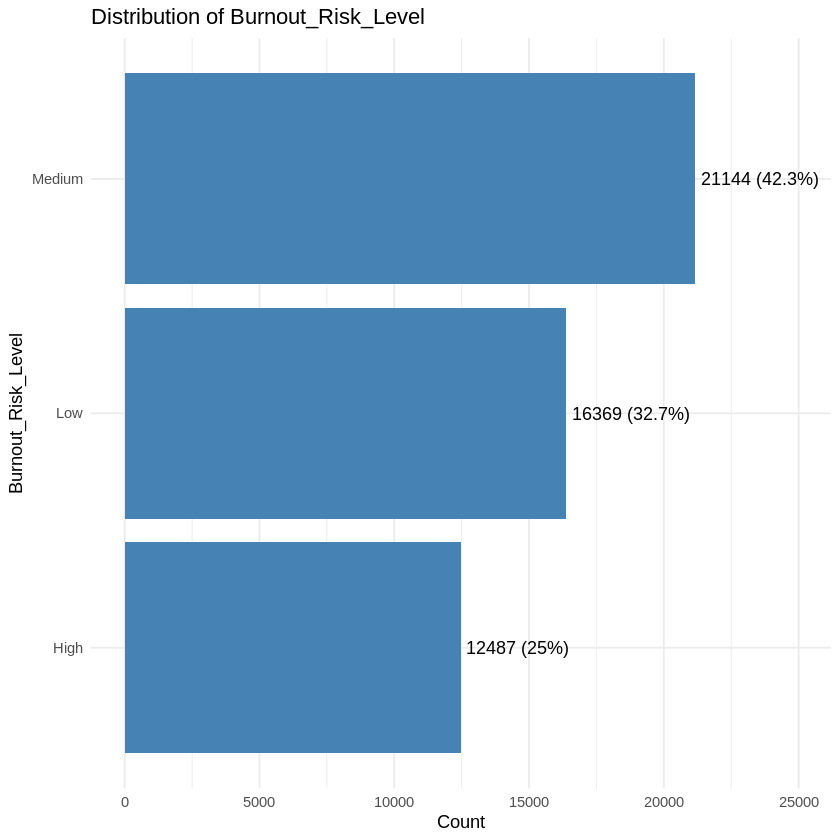

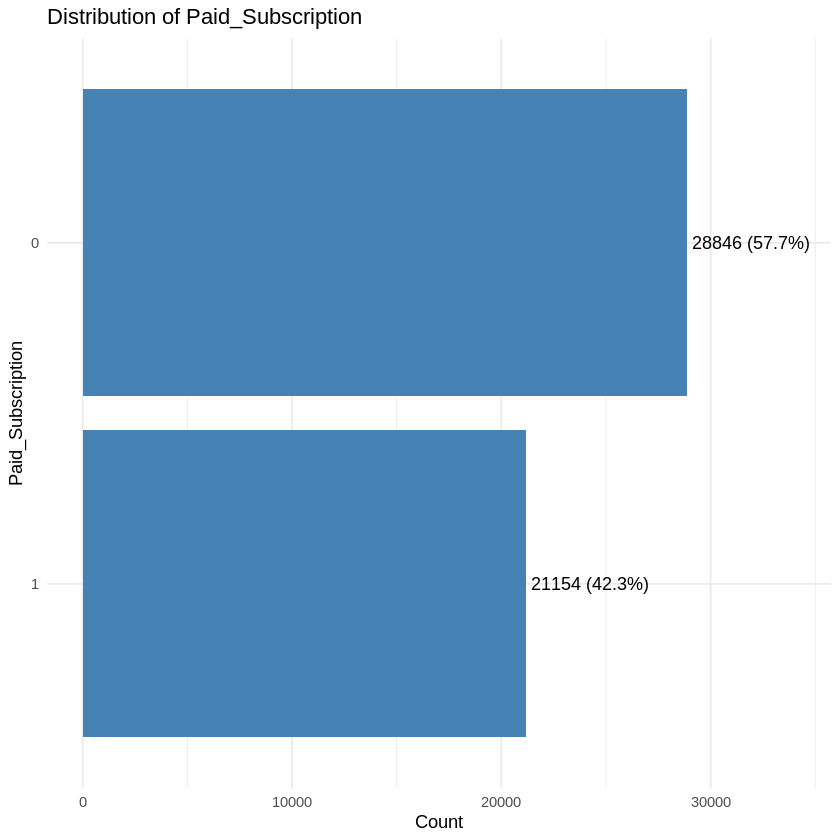

In [13]:
# Better bar charts with count and percentage labels

categorical_vars <- c(
  df %>% select(where(is.character)) %>% names(),
  "Paid_Subscription"
)

for (var in categorical_vars) {

  plot_data <- df %>%
    count(.data[[var]]) %>%
    mutate(
      percentage = n / sum(n) * 100,
      label = paste0(n, " (", round(percentage, 1), "%)")
    ) %>%
    arrange(n)

  p <- ggplot(plot_data, aes(x = reorder(as.factor(.data[[var]]), n), y = n)) +
    geom_col(fill = "steelblue") +
    geom_text(aes(label = label), hjust = -0.05, size = 3.8) +
    coord_flip() +
    theme_minimal() +
    labs(
      title = paste("Distribution of", var),
      x = var,
      y = "Count"
    ) +
    expand_limits(y = max(plot_data$n) * 1.18)

  print(p)
}

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,GPA_Change,Total_Study_Hours,AI_Time_Ratio
Pre_Semester_GPA,1.0000000000,-0.001084032,-0.005671308,-0.004620040,0.0007010104,-0.0006666078,0.92678087,0.09901886,-0.10403519,-0.003630669,0.002218466
Weekly_GenAI_Hours,-0.0010840316,1.000000000,0.008410604,-0.157367828,0.6654785561,0.2690796701,-0.01860023,-0.11809898,-0.04647928,0.825858444,0.807177021
Tool_Diversity,-0.0056713084,0.008410604,1.000000000,0.003564976,0.0060193675,0.0031885139,0.02526477,0.19695184,0.08140742,0.009737283,0.004857763
Traditional_Study_Hours,-0.0046200396,-0.157367828,0.003564976,1.000000000,-0.1026248317,-0.0409353765,0.13765332,0.14756512,0.37631655,0.426888066,-0.540265131
Perceived_AI_Dependency,0.0007010104,0.665478556,0.006019367,-0.102624832,1.0000000000,0.3076204878,-0.01418031,-0.08432432,-0.03934190,0.550790216,0.529708024
Anxiety_Level_During_Exams,-0.0006666078,0.269079670,0.003188514,-0.040935376,0.3076204878,1.0000000000,-0.01590870,-0.04155558,-0.04042007,0.223026306,0.214842240
Post_Semester_GPA,0.9267808745,-0.018600233,0.025264775,0.137653320,-0.0141803127,-0.0159087003,1.00000000,0.16961574,0.27714647,0.061566450,-0.057581588
Skill_Retention_Score,0.0990188571,-0.118098984,0.196951842,0.147565117,-0.0843243188,-0.0415555817,0.16961574,1.00000000,0.19583279,-0.023886414,-0.109796773
GPA_Change,-0.1040351940,-0.046479283,0.081407423,0.376316548,-0.0393419014,-0.0404200714,0.27714647,0.19583279,1.00000000,0.172312007,-0.158147770
Total_Study_Hours,-0.0036306689,0.825858444,0.009737283,0.426888066,0.5507902156,0.2230263064,0.06156645,-0.02388641,0.17231201,1.000000000,0.430656394


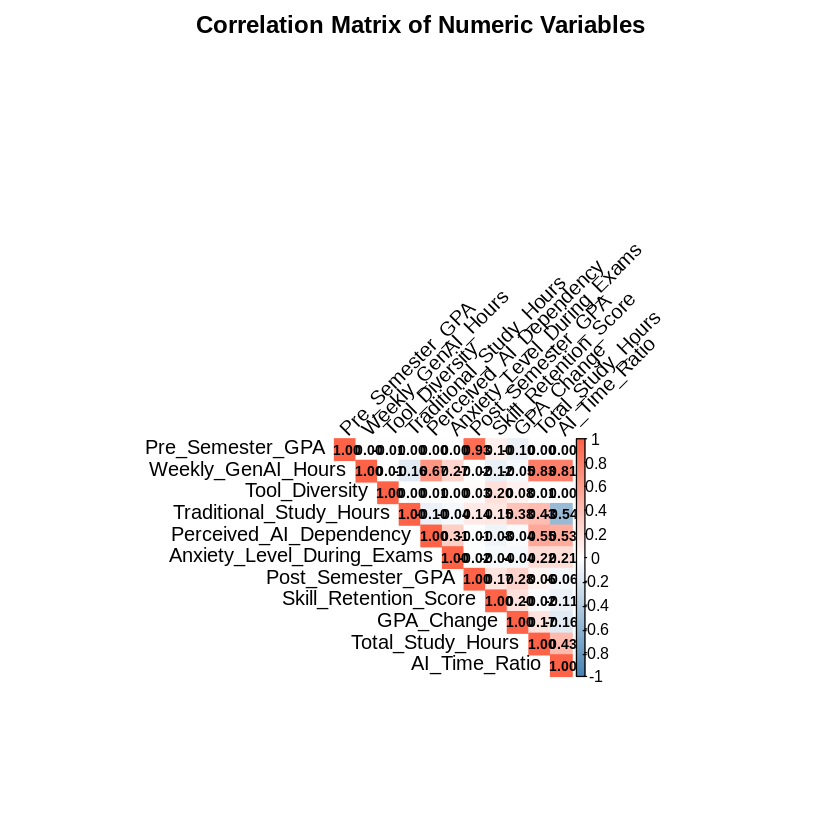

In [14]:
# Correlation matrix for numeric variables

numeric_vars <- df %>%
  select(where(is.numeric)) %>%
  select(-Paid_Subscription) %>%
  names()

cor_matrix <- df %>%
  select(all_of(numeric_vars)) %>%
  cor(use = "complete.obs")

cor_matrix

# Correlation heatmap

corrplot(
  cor_matrix,
  method = "color",
  type = "upper",
  tl.col = "black",
  tl.srt = 45,
  addCoef.col = "black",
  number.cex = 0.7,
  col = colorRampPalette(c("steelblue", "white", "tomato"))(200),
  title = "Correlation Matrix of Numeric Variables",
  mar = c(0, 0, 2, 0)
)

`geom_smooth()` using formula = 'y ~ x'


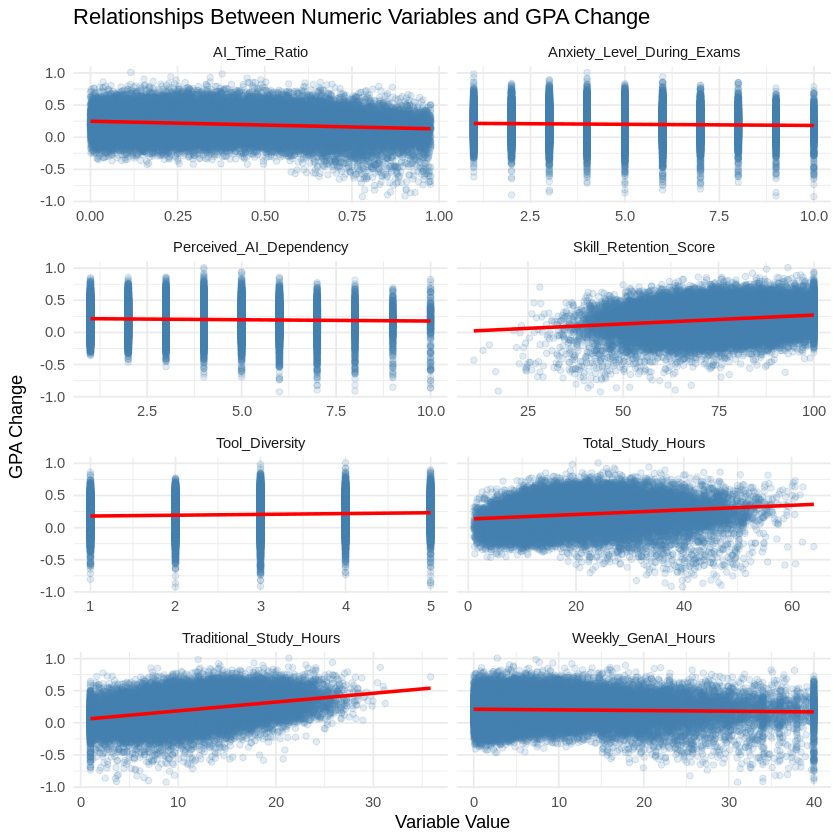

In [15]:
# Scatterplots: numeric variables vs GPA_Change

relationship_vars <- c(
  "Weekly_GenAI_Hours",
  "Traditional_Study_Hours",
  "Total_Study_Hours",
  "AI_Time_Ratio",
  "Perceived_AI_Dependency",
  "Anxiety_Level_During_Exams",
  "Skill_Retention_Score",
  "Tool_Diversity"
)

df %>%
  select(all_of(c(relationship_vars, "GPA_Change"))) %>%
  pivot_longer(cols = all_of(relationship_vars),
               names_to = "variable",
               values_to = "value") %>%
  ggplot(aes(x = value, y = GPA_Change)) +
  geom_point(alpha = 0.15, color = "steelblue") +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  facet_wrap(~ variable, scales = "free_x", ncol = 2) +
  theme_minimal() +
  labs(
    title = "Relationships Between Numeric Variables and GPA Change",
    x = "Variable Value",
    y = "GPA Change"
  )

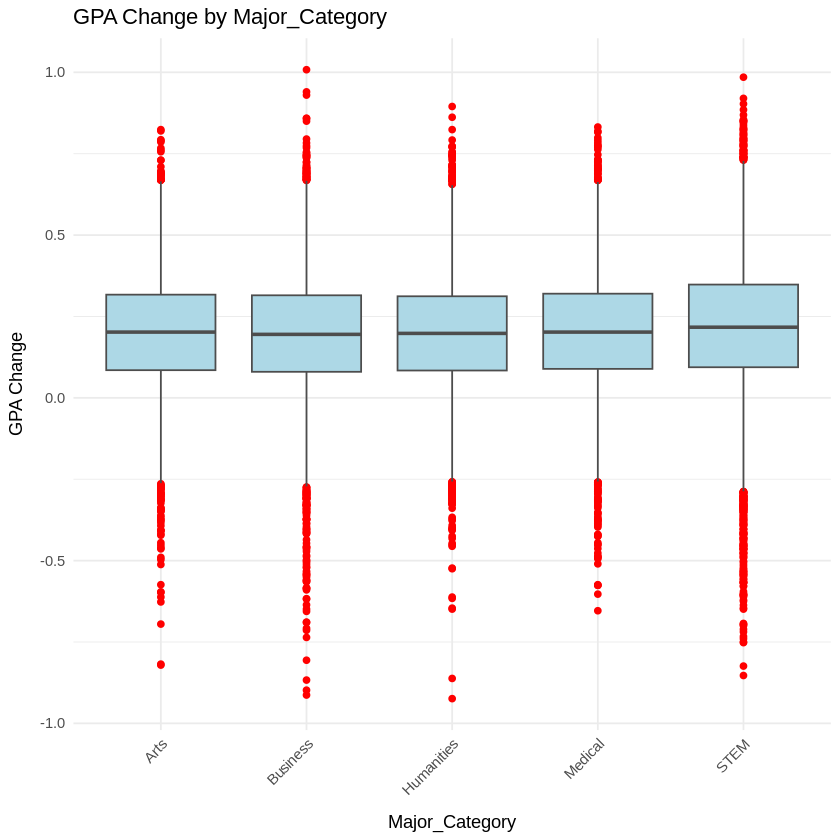

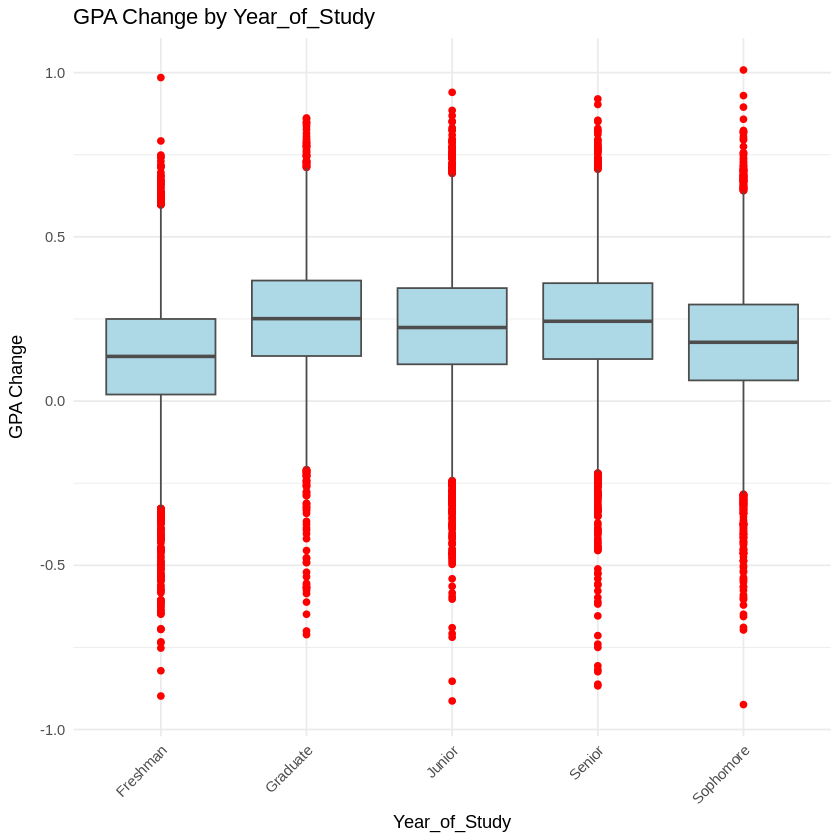

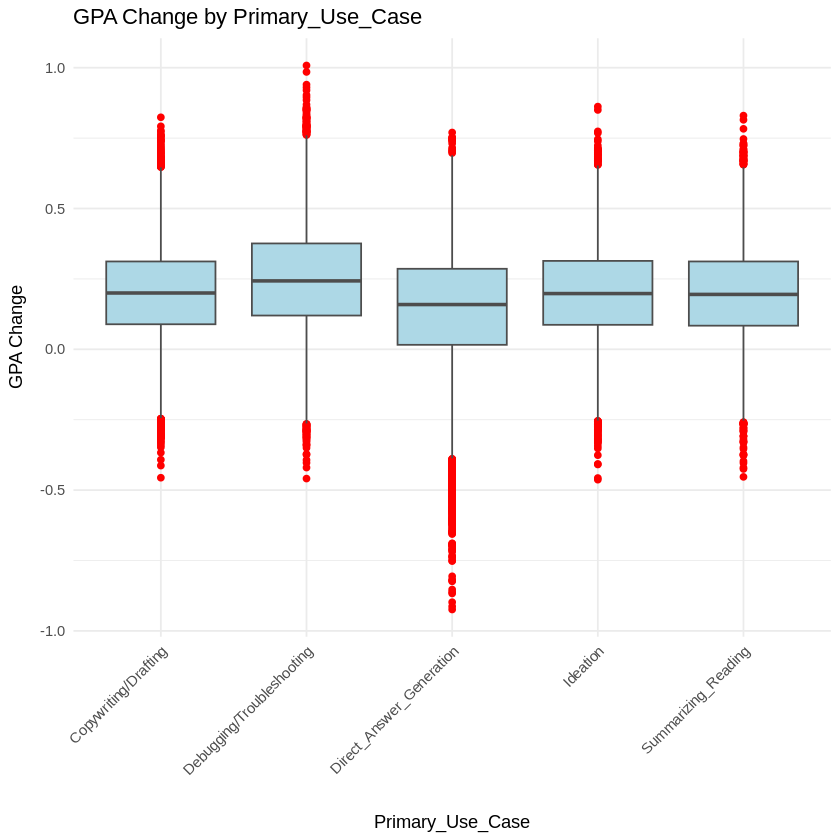

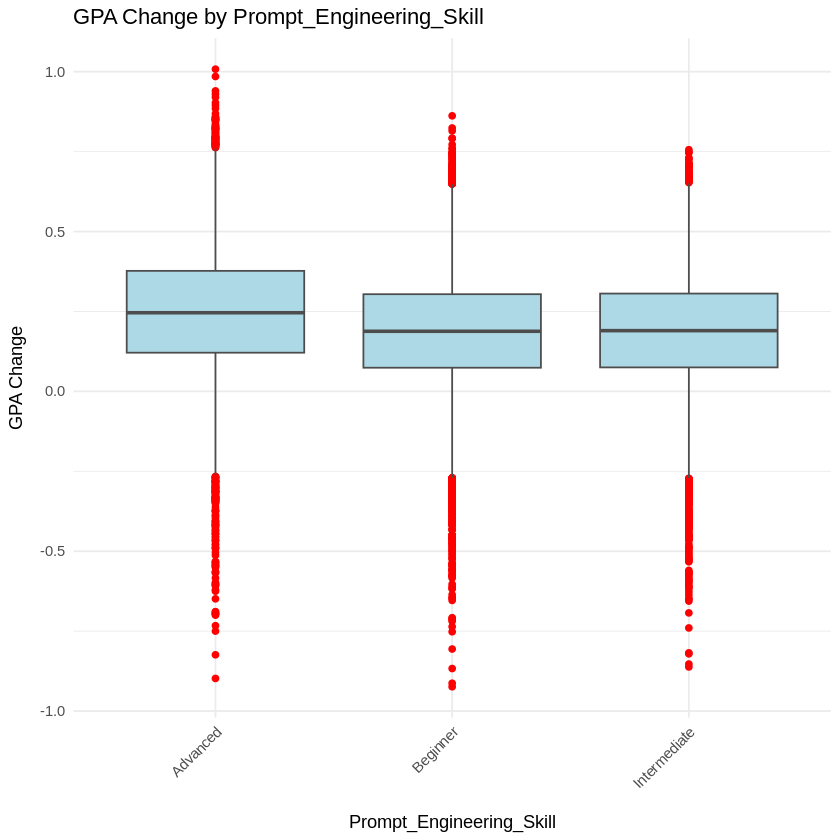

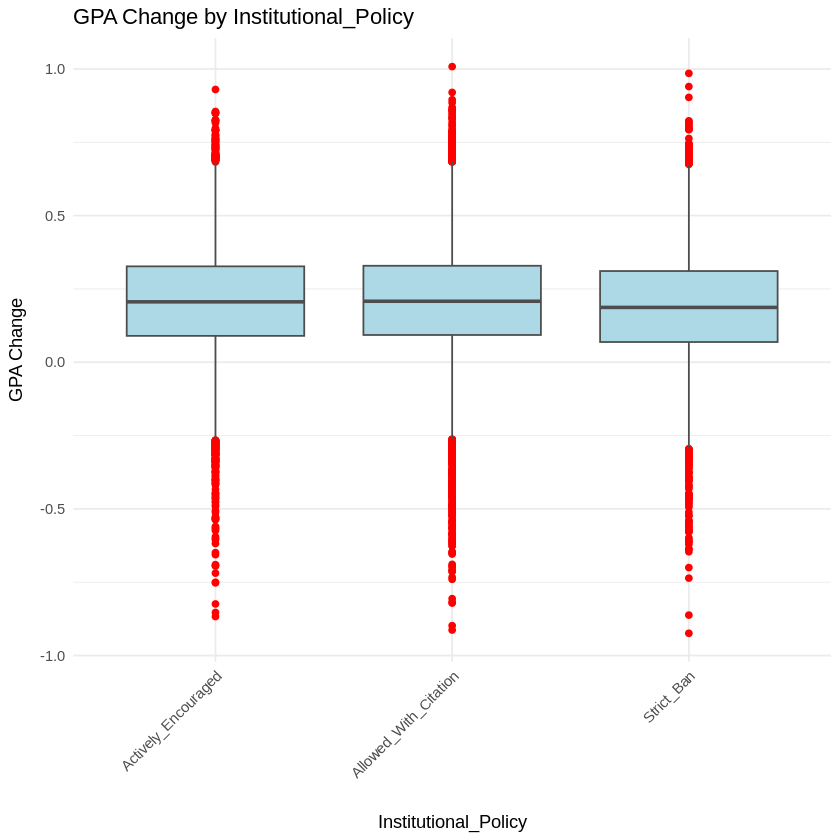

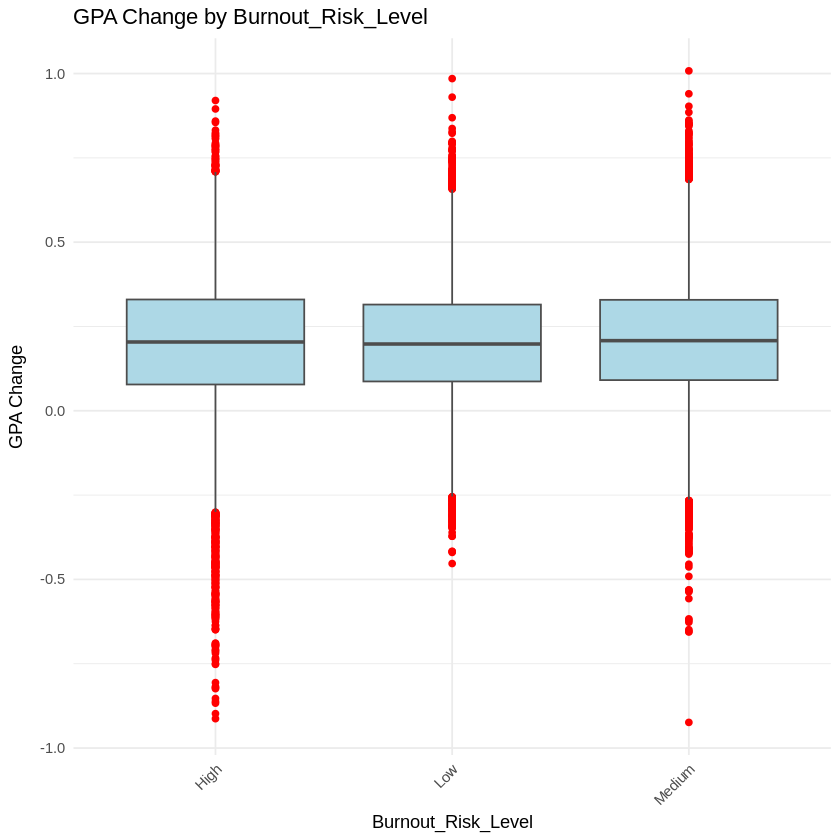

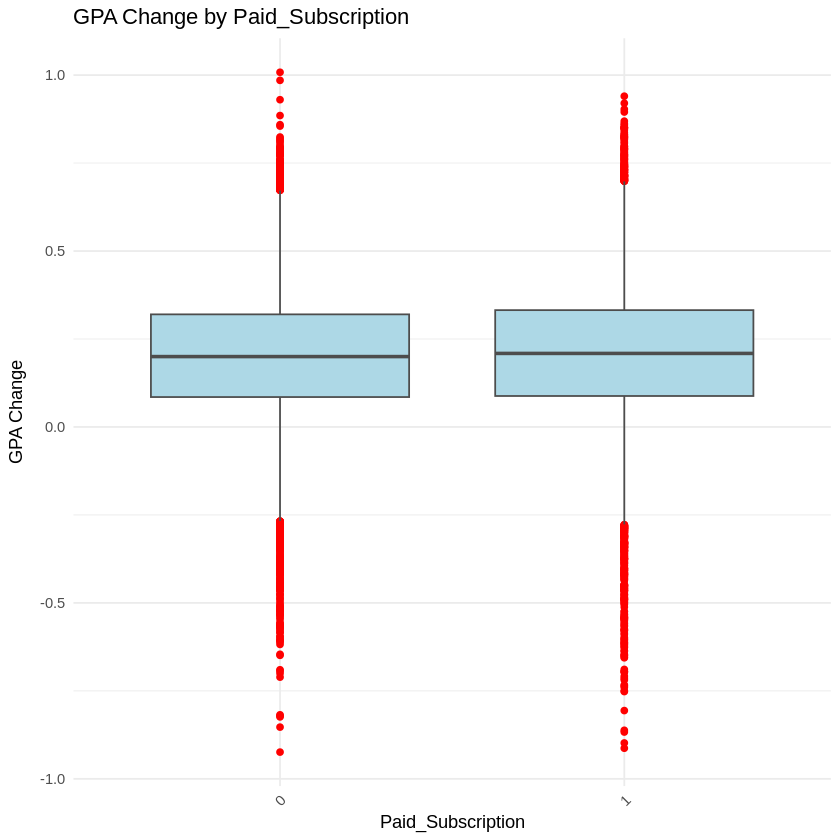

In [16]:
# Boxplots: GPA_Change by each categorical variable
# One plot for each categorical variable

categorical_vars <- c(
  df %>% select(where(is.character)) %>% names(),
  "Paid_Subscription"
)

for (var in categorical_vars) {

  plot_data <- df %>%
    mutate(category = as.factor(.data[[var]]))

  p <- ggplot(plot_data, aes(x = category, y = GPA_Change)) +
    geom_boxplot(fill = "lightblue", color = "gray30", outlier.color = "red") +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1)
    ) +
    labs(
      title = paste("GPA Change by", var),
      x = var,
      y = "GPA Change"
    )

  print(p)
}

決定分析AI訂閱使用者 vs 未訂閱使用者  
1.學習成效比較(GPA變化率)  2.學習技能保留比較 3.每週 AI 使用時數比較

In [17]:
library(tidyverse)

df_analysis <- read.csv("ai_student_impact_dataset_final.csv")

df_analysis$Paid_Label <- factor(
  df_analysis$Paid_Subscription,
  levels = c(0, 1),
  labels = c("Non-paid", "Paid")
)

if (!dir.exists("outputs")) {
  dir.create("outputs")
}

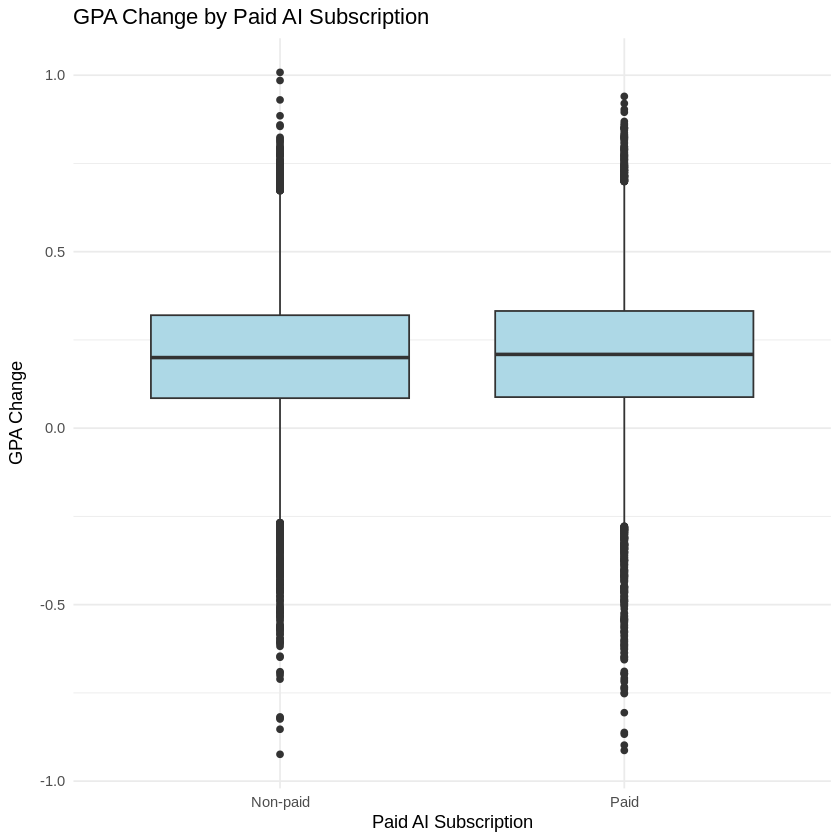

In [18]:
p_gpa <- ggplot(df_analysis, aes(x = Paid_Label, y = GPA_Change)) +
  geom_boxplot(fill = "lightblue") +
  labs(
    title = "GPA Change by Paid AI Subscription",
    x = "Paid AI Subscription",
    y = "GPA Change"
  ) +
  theme_minimal()

print(p_gpa)

ggsave("outputs/gpa_change_by_paid_subscription.png",
       p_gpa, width = 8, height = 6, dpi = 150)

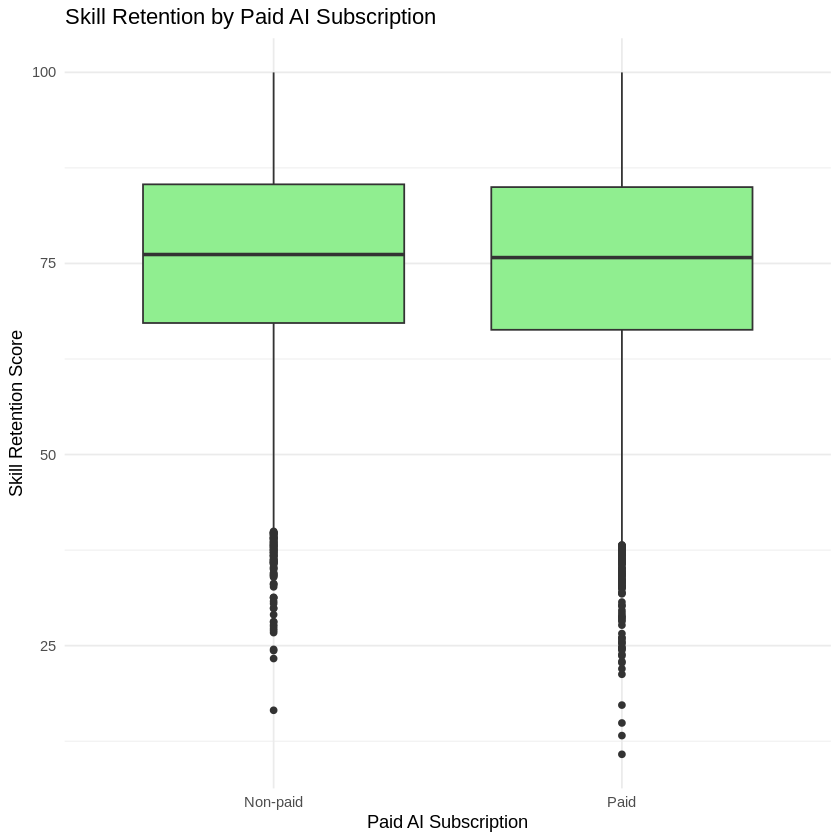

In [19]:
p_retention <- ggplot(df_analysis, aes(x = Paid_Label, y = Skill_Retention_Score)) +
  geom_boxplot(fill = "lightgreen") +
  labs(
    title = "Skill Retention by Paid AI Subscription",
    x = "Paid AI Subscription",
    y = "Skill Retention Score"
  ) +
  theme_minimal()

print(p_retention)

ggsave("outputs/skill_retention_by_paid_subscription.png",
       p_retention, width = 8, height = 6, dpi = 150)

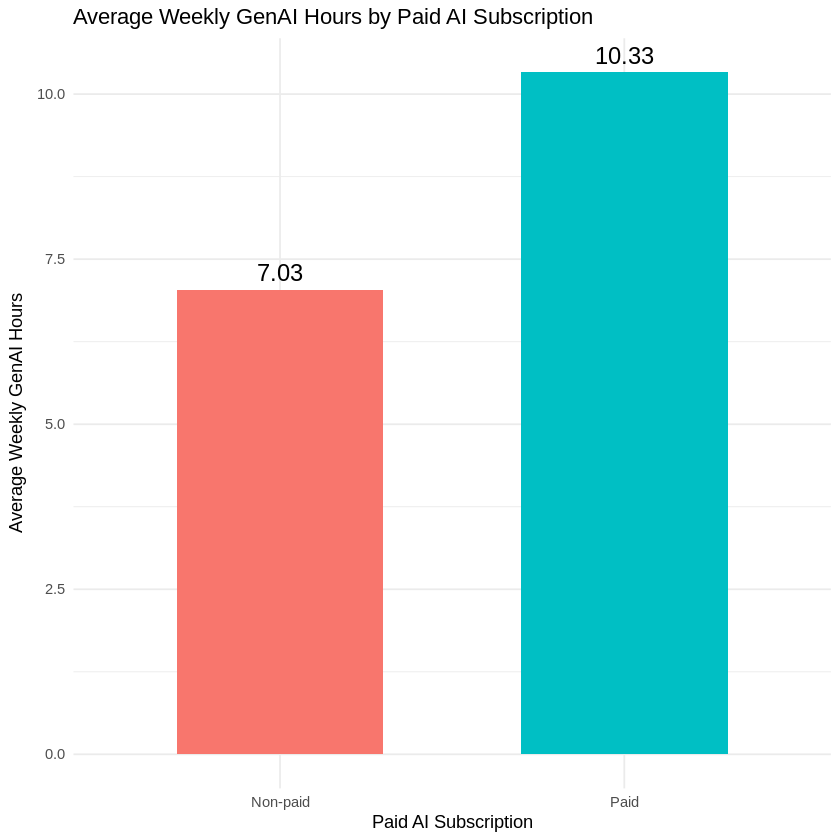

In [20]:
weekly_hours_summary <- df_analysis %>%
  group_by(Paid_Label) %>%
  summarise(
    mean_weekly_ai_hours = mean(Weekly_GenAI_Hours),
    .groups = "drop"
  )

p_hours <- ggplot(
  weekly_hours_summary,
  aes(x = Paid_Label, y = mean_weekly_ai_hours, fill = Paid_Label)
) +
  geom_col(width = 0.6) +
  geom_text(
    aes(label = round(mean_weekly_ai_hours, 2)),
    vjust = -0.5,
    size = 5
  ) +
  labs(
    title = "Average Weekly GenAI Hours by Paid AI Subscription",
    x = "Paid AI Subscription",
    y = "Average Weekly GenAI Hours"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

print(p_hours)

ggsave("outputs/weekly_genai_hours_by_paid_subscription.png",
       p_hours, width = 8, height = 6, dpi = 150)

## Stastical Methods

In [21]:
if (!requireNamespace("effsize", quietly = TRUE)) {
  install.packages("effsize")
}
library(effsize)
library(ggplot2)

# ── 1. 確保輸出資料夾存在 ──
if (!dir.exists("outputs")) {
  dir.create("outputs")
}

# ── 2. 載入前處理好的乾淨資料 ──
df_final <- readRDS("ai_student_impact_dataset_final.rds")

# ── 3. 萃取付費組與免費組的數值 ──
gpa_paid <- df_final$GPA_Change[df_final$Paid_Subscription == 1]
gpa_free <- df_final$GPA_Change[df_final$Paid_Subscription == 0]

skill_paid <- df_final$Skill_Retention_Score[df_final$Paid_Subscription == 1]
skill_free <- df_final$Skill_Retention_Score[df_final$Paid_Subscription == 0]

# 每週 AI 時數 (Weekly_GenAI_Hours)
hours_paid <- df_final$Weekly_GenAI_Hours[df_final$Paid_Subscription == 1]
hours_free <- df_final$Weekly_GenAI_Hours[df_final$Paid_Subscription == 0]

# AI 時間佔比 (AI_Time_Ratio)
ratio_paid <- df_final$AI_Time_Ratio[df_final$Paid_Subscription == 1]
ratio_free <- df_final$AI_Time_Ratio[df_final$Paid_Subscription == 0]

# ── 4. 執行獨立雙樣本 T 檢定 ──
cat("=== 分析一: 付費訂閱對【GPA 變化】的影響 ===\n")
t_test_gpa <- t.test(gpa_paid, gpa_free, alternative = "greater")
print(t_test_gpa)
gpa_cohen <- cohen.d(gpa_paid, gpa_free)
cat("\n[效應量 Cohen's d]:\n")
print(gpa_cohen)

cat("\n=== 分析二: 付費訂閱對【技能保留分數】的影響 ===\n")
t_test_skill <- t.test(skill_paid, skill_free, alternative = "greater")
print(t_test_skill)
skill_cohen <- cohen.d(skill_paid, skill_free)
cat("\n[效應量 Cohen's d]:\n")
print(skill_cohen)

cat("=== 分析三：付費訂閱對【每週 AI 使用時數】的影響 ===\n")
t_test_hours <- t.test(hours_paid, hours_free, alternative = "two.sided")
print(t_test_hours)
cat("\n[效應量 Cohen's d]:\n")
print(cohen.d(hours_paid, hours_free))

cat("\n======================================================\n")

cat("\n=== 分析四：付費訂閱對【AI 時間佔比】的影響 ===\n")
t_test_ratio <- t.test(ratio_paid, ratio_free, alternative = "two.sided")
print(t_test_ratio)
cat("\n[效應量 Cohen's d]:\n")
print(cohen.d(ratio_paid, ratio_free))


=== 分析一: 付費訂閱對【GPA 變化】的影響 ===

	Welch Two Sample t-test

data:  gpa_paid and gpa_free
t = 3.8223, df = 43817, p-value = 6.62e-05
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 0.003726446         Inf
sample estimates:
mean of x mean of y 
0.2069710 0.2004295 


[效應量 Cohen's d]:

Cohen's d

d estimate: 0.03495052 (negligible)
95 percent confidence interval:
     lower      upper 
0.01720712 0.05269392 


=== 分析二: 付費訂閱對【技能保留分數】的影響 ===

	Welch Two Sample t-test

data:  skill_paid and skill_free
t = -5.3646, df = 44881, p-value = 1
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 -0.8459471        Inf
sample estimates:
mean of x mean of y 
 75.42461  76.07204 


[效應量 Cohen's d]:

Cohen's d

d estimate: -0.04876003 (negligible)
95 percent confidence interval:
      lower       upper 
-0.06650468 -0.03101537 

=== 分析三：付費訂閱對【每週 AI 使用時數】的影響 ===

	Welch Two Sample t-test

data:  hours_paid an

=== ANOVA 檢定：提示詞技巧對 GPA 進步量的影響 ===
                            Df Sum Sq Mean Sq F value Pr(>F)    
Prompt_Engineering_Skill     2   38.5  19.243   561.5 <2e-16 ***
Residuals                49997 1713.5   0.034                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

=== Tukey 事後檢定 (各等級兩兩比較) ===
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = GPA_Change ~ Prompt_Engineering_Skill, data = df_final)

$Prompt_Engineering_Skill
                             diff          lwr         upr     p adj
Intermediate-Beginner 0.001680584 -0.002881986 0.006243154 0.6634908
Advanced-Beginner     0.062852879  0.057973171 0.067732588 0.0000000
Advanced-Intermediate 0.061172295  0.056245721 0.066098870 0.0000000



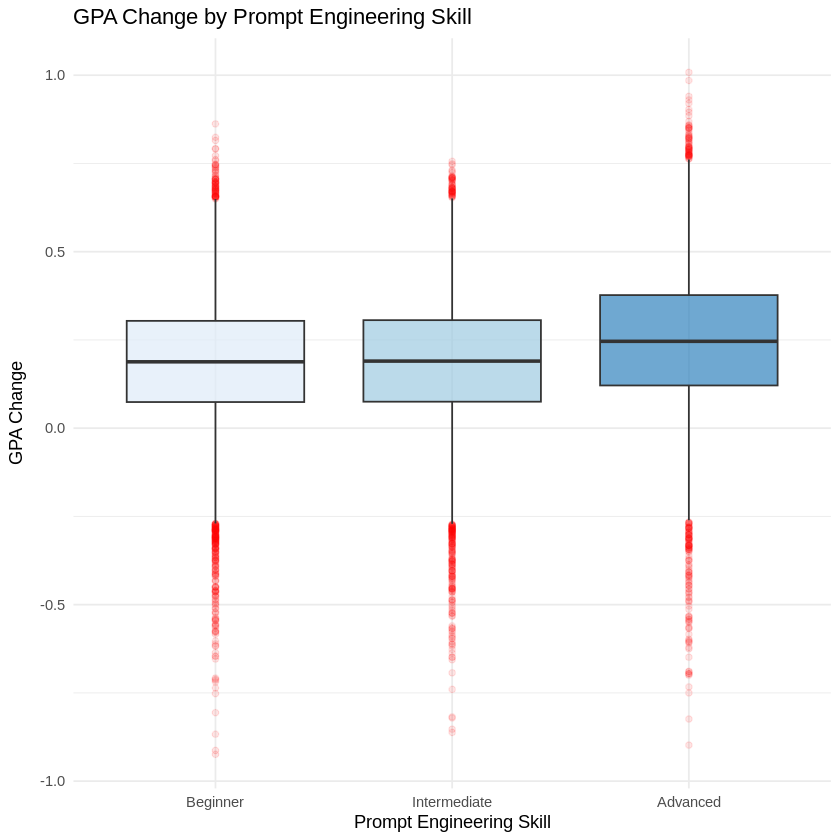

In [22]:
library(ggplot2)

# ── 1. 載入資料 ──
df_final <- readRDS("ai_student_impact_dataset_final.rds")

# 確保提示詞等級的順序是正確的 (初階 -> 中階 -> 高階)
df_final$Prompt_Engineering_Skill <- factor(
  df_final$Prompt_Engineering_Skill,
  levels = c("Beginner", "Intermediate", "Advanced"),
  ordered = TRUE
)

# ── 2. 執行 ANOVA 檢定 ──
cat("=== ANOVA 檢定：提示詞技巧對 GPA 進步量的影響 ===\n")
anova_prompt <- aov(GPA_Change ~ Prompt_Engineering_Skill, data = df_final)
print(summary(anova_prompt))

# ── 3. 執行 Tukey 事後檢定 (抓出到底是誰跟誰有差) ──
cat("\n=== Tukey 事後檢定 (各等級兩兩比較) ===\n")
tukey_prompt <- TukeyHSD(anova_prompt)
print(tukey_prompt)

# ── 4. 繪製盒鬚圖 ──
p_prompt <- ggplot(df_final, aes(x = Prompt_Engineering_Skill, y = GPA_Change, fill = Prompt_Engineering_Skill)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.alpha = 0.1) +
  scale_fill_brewer(palette = "Blues") +
  labs(title = "GPA Change by Prompt Engineering Skill",
       x = "Prompt Engineering Skill",
       y = "GPA Change") +
  theme_minimal() +
  theme(legend.position = "none")

print(p_prompt)

# 存檔
if (!dir.exists("outputs")) dir.create("outputs")
ggsave("outputs/anova_prompt_gpa.png", p_prompt, width = 8, height = 6, dpi = 150)

## Data Mining Techniques

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘arules’


The following object is masked from ‘package:dplyr’:

    recode


The following objects are masked from ‘package:base’:

    abbreviate, write


Loading required package: sysfonts

Loading required package: showtextdb



R 套件與中文字體設定完成
準備工作完成，開始分析...
資料筆數：50,000
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
         NA    0.1    1 none FALSE            TRUE       5    0.05      1
 maxlen            target  ext
     10 frequent itemsets TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 2500 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[41 item(s), 50000 transaction(s)] done [0.08s].
sorting and recoding items ... [41 item(s)] done [0.01s].
creating transaction tree ... done [0.04s].
checking subsets of size 1 2 3 4 5 done [0.26s].
sorting transactions ... done [0.02s].
writing ... [1439 set(s)] done [0.00s].
creating S4 object  ... done [0.01s].
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.5    0.1    1 none FALSE            TRUE       5    0.05      

Warning message in viridisLite::viridis(n, alpha, begin, end, direction, option):
“Option 'YlOrRd' does not exist. Defaulting to 'viridis'.”


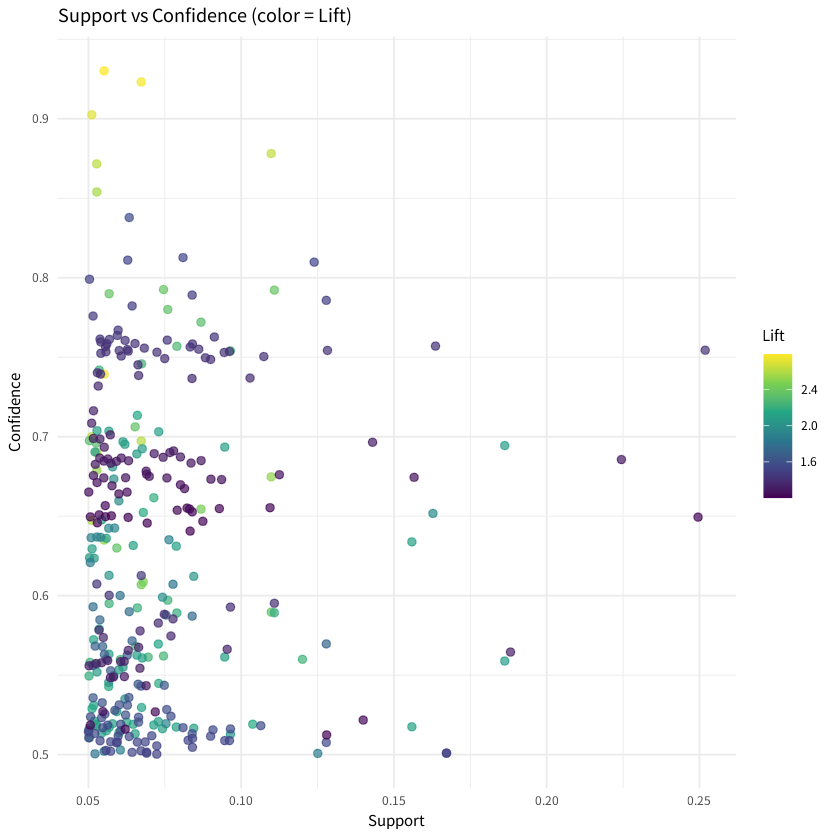

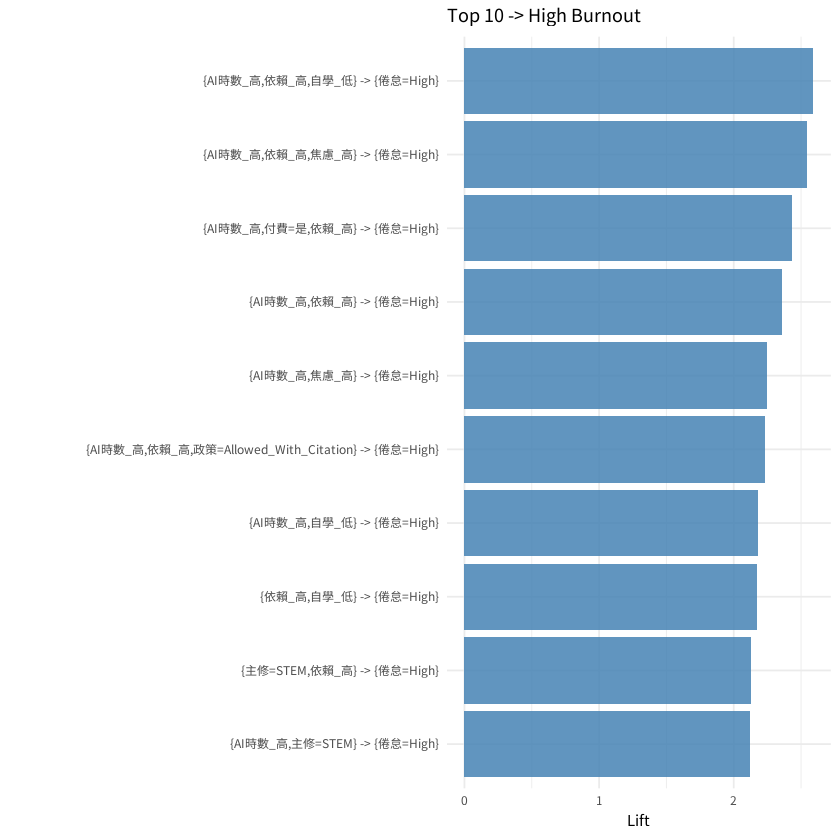


分析完成！耗時 20.2 秒
已將結果打包為 association_rules_output.zip，請從左側 Files 介面下載。


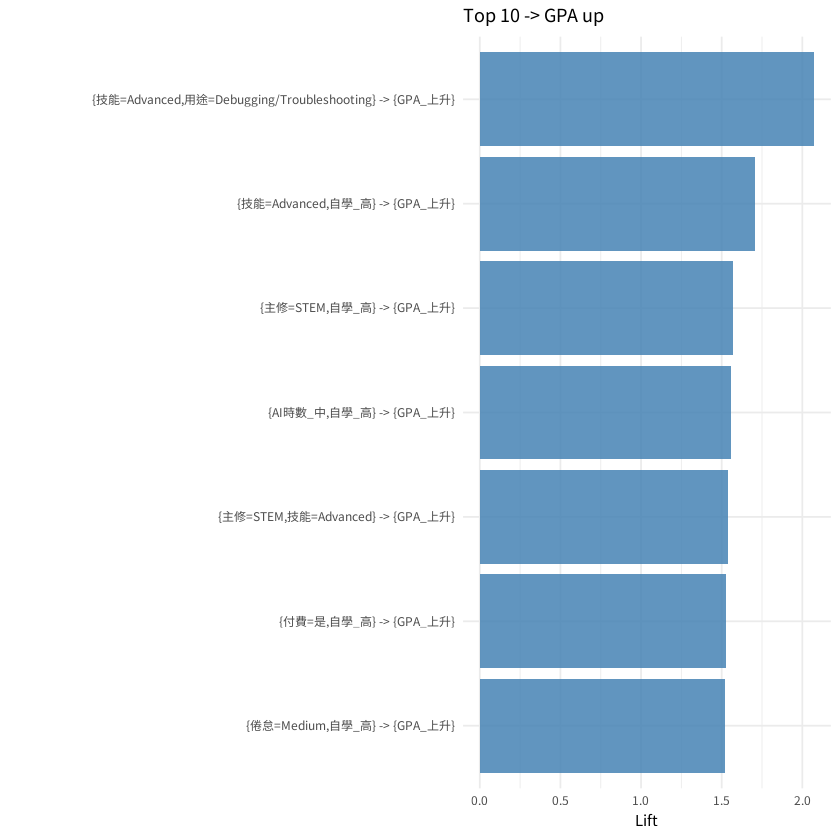

In [23]:
# ── 1. 安裝並載入 R 套件與中文字體設定 ────────────────────────────────
required_pkgs <- c("arules", "ggplot2", "showtext")
for (pkg in required_pkgs) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}
library(arules)
library(ggplot2)
library(showtext)

# 下載並設定 Google 思源黑體 (Noto Sans TC) 以解決圖表中文亂碼
font_add_google("Noto Sans TC", "noto")
showtext_auto()

cat("R 套件與中文字體設定完成\n")

# ── 2. 設定參數與路徑 ──────────────────────────────────
DATA_PATH <- "ai_student_impact_dataset_final.csv"
OUTPUT_DIR <- "outputs/association_rules"

MIN_SUPPORT    <- 0.05
MIN_CONFIDENCE <- 0.5
MIN_LIFT       <- 1.2
TOP_N          <- 20

dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

# ── 3. 函式定義 ────────────────────────────────────────
load_data <- function() {
  df <- read.csv(DATA_PATH, stringsAsFactors = FALSE)
  df$Year_of_Study[is.na(df$Year_of_Study)] <- "Unknown"
  df
}

bin_numeric <- function(x, labels, q = 3) {
  probs <- seq(0, 1, length.out = q + 1)
  brk <- unique(quantile(x, probs = probs, na.rm = TRUE))
  if (length(brk) < 2) return(factor(rep(labels[1], length(x)), levels = labels))
  n_labels <- length(brk) - 1
  cut(x, breaks = brk, labels = labels[seq_len(n_labels)], include.lowest = TRUE)
}

to_transactions <- function(df) {
  d <- df
  d$AI_Hours    <- bin_numeric(d$Weekly_GenAI_Hours, c("AI時數_低", "AI時數_中", "AI時數_高"))
  d$GPA_Level   <- bin_numeric(d$GPA_Change, c("GPA_下降", "GPA_持平", "GPA_上升"))
  d$Study_Hours <- bin_numeric(d$Traditional_Study_Hours, c("自學_低", "自學_中", "自學_高"))
  d$AI_Dep      <- bin_numeric(d$Perceived_AI_Dependency, c("依賴_低", "依賴_中", "依賴_高"))
  d$Anxiety     <- bin_numeric(d$Anxiety_Level_During_Exams, c("焦慮_低", "焦慮_中", "焦慮_高"))

  trans_list <- vector("list", nrow(d))
  for (i in seq_len(nrow(d))) {
    row <- d[i, ]
    trans_list[[i]] <- c(
      paste0("主修=", row$Major_Category),
      paste0("年級=", row$Year_of_Study),
      paste0("用途=", row$Primary_Use_Case),
      paste0("技能=", row$Prompt_Engineering_Skill),
      paste0("政策=", row$Institutional_Policy),
      paste0("倦怠=", row$Burnout_Risk_Level),
      as.character(row$AI_Hours), as.character(row$GPA_Level),
      as.character(row$Study_Hours), as.character(row$AI_Dep),
      as.character(row$Anxiety),
      if (row$Paid_Subscription == 1) "付費=是" else "付費=否"
    )
  }
  trans_list
}

rules_to_dataframe <- function(rules) {
  lhs_labels <- labels(lhs(rules))
  rhs_labels <- labels(rhs(rules))
  antecedents_str <- vapply(lhs_labels, function(x) paste(x, collapse = ", "), character(1))
  consequents_str <- vapply(rhs_labels, function(x) paste(x, collapse = ", "), character(1))

  q <- quality(rules)

  data.frame(
    antecedents_str = antecedents_str, consequents_str = consequents_str,
    support = q[, "support"], confidence = q[, "confidence"],
    lift = q[, "lift"],
    stringsAsFactors = FALSE
  )
}

write_excel_csv <- function(df, filename) {
  con <- file(filename, open = "w", encoding = "UTF-8")
  cat("\ufeff", file = con, sep = "") # 寫入 UTF-8 BOM 標頭，強迫 Excel 用 UTF-8 開啟
  write.csv(df, con, row.names = FALSE)
  close(con)
}

filter_rules_by_consequent <- function(rules_df, keyword, filename) {
  sub <- rules_df[grepl(keyword, rules_df$consequents_str, fixed = TRUE), ]
  sub <- sub[order(-sub$lift), ]
  # 改用新的 write_excel_csv
  write_excel_csv(sub[, c("antecedents_str", "consequents_str", "support", "confidence", "lift")],
                  file.path(OUTPUT_DIR, filename))
  sub
}

cat("準備工作完成，開始分析...\n")

# ── 4. 分析流程 ────────────────────────────────────────
t0 <- proc.time()

# 步驟 1：資料項目化
df <- load_data()
trans_list <- to_transactions(df)
trans <- as(trans_list, "transactions")
cat(sprintf("資料筆數：%s\n", format(nrow(df), big.mark = ",")))

# 步驟 2：Apriori 頻繁項目集
itemsets <- apriori(trans, parameter = list(supp = MIN_SUPPORT, target = "frequent itemsets", minlen = 1))
itemsets_df <- as(itemsets, "data.frame")
itemsets_df <- itemsets_df[order(-itemsets_df$support), ]
# 改用新的 write_excel_csv
write_excel_csv(itemsets_df, file.path(OUTPUT_DIR, "01_frequent_itemsets.csv"))

# 步驟 3：關聯規則
rules <- apriori(trans, parameter = list(supp = MIN_SUPPORT, conf = MIN_CONFIDENCE, target = "rules", minlen = 2))
rules <- subset(rules, lift >= MIN_LIFT)
rules_df <- rules_to_dataframe(rules)
rules_df <- rules_df[order(-rules_df$lift, -rules_df$confidence), ]
# 改用新的 write_excel_csv
write_excel_csv(rules_df, file.path(OUTPUT_DIR, "02_association_rules_all.csv"))

burnout_rules <- filter_rules_by_consequent(rules_df, "倦怠=High", "04_rules_burnout_high.csv")
gpa_rules     <- filter_rules_by_consequent(rules_df, "GPA_上升", "05_rules_gpa_up.csv")

# 步驟 4：視覺化
p1 <- ggplot(rules_df, aes(x = support, y = confidence, color = lift)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_viridis_c(option = "YlOrRd") +
  labs(x = "Support", y = "Confidence", color = "Lift",
       title = "Support vs Confidence (color = Lift)") +
  theme_minimal(base_family = "noto")
ggsave(file.path(OUTPUT_DIR, "03_support_confidence_lift.png"), p1, width = 8, height = 6, dpi = 150)
print(p1)

plot_top <- function(keyword, title, filename) {
  sub <- rules_df[grepl(keyword, rules_df$consequents_str, fixed = TRUE), ]
  sub <- head(sub[order(-sub$lift), ], 10)
  if (nrow(sub) == 0) return(invisible(NULL))
  sub$label <- factor(paste0(sub$antecedents_str, " -> ", sub$consequents_str),
                      levels = rev(paste0(sub$antecedents_str, " -> ", sub$consequents_str)))
  p <- ggplot(sub, aes(x = lift, y = label)) +
    geom_col(fill = "steelblue", alpha = 0.85) +
    labs(x = "Lift", y = NULL, title = title) +
    theme_minimal(base_family = "noto")
  ggsave(file.path(OUTPUT_DIR, filename), p, width = 9, height = 5, dpi = 150)
  print(p)
}

plot_top("倦怠=High", "Top 10 -> High Burnout", "06_top_burnout_rules.png")
plot_top("GPA_上升", "Top 10 -> GPA up", "07_top_gpa_up_rules.png")

# 步驟 5：重點解讀與打包下載
elapsed <- (proc.time() - t0)[["elapsed"]]
cat(sprintf("\n分析完成！耗時 %.1f 秒\n", elapsed))

# 在 R 中打包輸出的檔案為 zip
zip("association_rules_output.zip", files = "outputs")
cat("已將結果打包為 association_rules_output.zip，請從左側 Files 介面下載。\n")

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine




                                  Low     Medium        High
Weekly_GenAI_Hours         76.4538072 -2.5207041 102.4607653
Perceived_AI_Dependency    19.4937515 -3.3114913  18.9032337
Traditional_Study_Hours     7.3414774  0.8791257   8.1478901
Anxiety_Level_During_Exams  1.9626235 -2.1524840  14.8788287
Tool_Diversity              0.5690494 -1.1433038   0.2813586
GPA_Change                  2.4100894  2.7086334   2.6100128
                           MeanDecreaseAccuracy MeanDecreaseGini
Weekly_GenAI_Hours                  118.1739727         9331.585
Perceived_AI_Dependency              23.8145215         2358.830
Traditional_Study_Hours               7.9576294         7066.628
Anxiety_Level_During_Exams            6.0556246         2696.178
Tool_Diversity                       -0.2937598         2188.621
GPA_Change                            4.3229828         7050.690


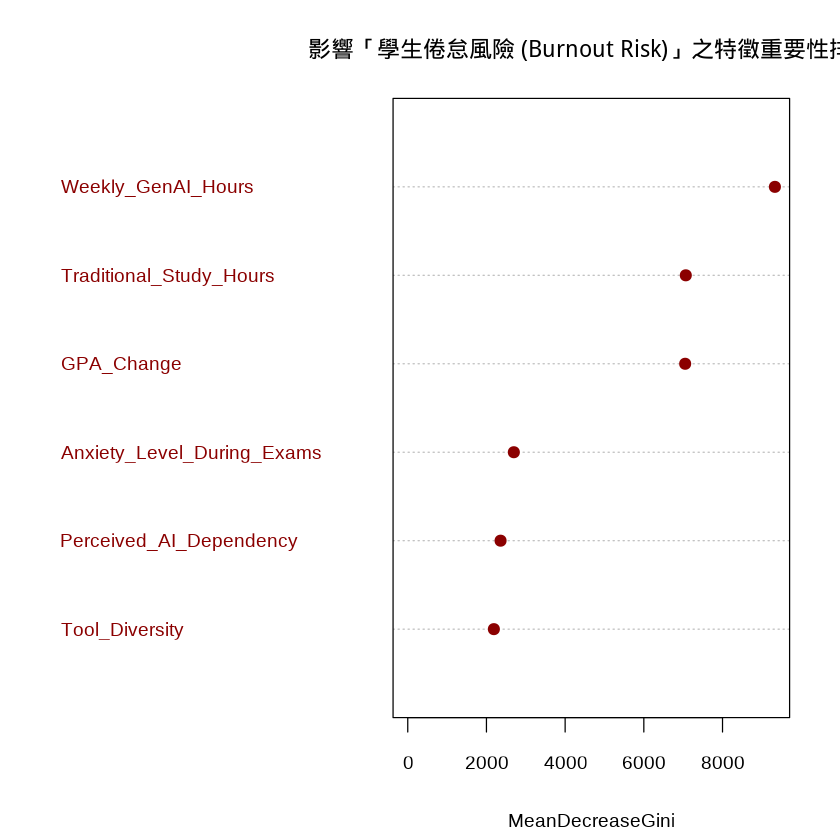

In [24]:
# ── 1. 安裝並載入隨機森林套件 ──
if (!requireNamespace("randomForest", quietly = TRUE)) {
  install.packages("randomForest")
}
library(randomForest)

# ── 2. 讀取您已經前處理好的乾淨資料 ──
df_final <- readRDS("ai_student_impact_dataset_final.rds")

# ── 3. 建立隨機森林分類模型 ──
# 目標變數：Burnout_Risk_Level (低/中/高)
# 預測變數：放入您認為可能影響倦怠的各項數值與類別特徵
set.seed(42) # 設定亂數種子確保結果可重現
rf_model <- randomForest(
  Burnout_Risk_Level ~ Weekly_GenAI_Hours + Perceived_AI_Dependency +
                       Traditional_Study_Hours + Anxiety_Level_During_Exams +
                       Tool_Diversity + GPA_Change,
  data = df_final,
  ntree = 100,           # 建立 100 棵決策樹
  importance = TRUE      # 關鍵參數：開啟特徵重要性計算
)

# ── 4. 提取並繪製「特徵重要性排名」──
# 畫出 MeanDecreaseGini (吉尼不純度減少量)，數值越高代表該特徵對預測倦怠越重要
varImpPlot(rf_model,
           type = 2,
           main = "影響「學生倦怠風險 (Burnout Risk)」之特徵重要性排名",
           pch = 19,
           color = "darkred",
           cex = 1.2)

# 若想看具體的數據排名，可以印出這個矩陣
print(importance(rf_model))

R 套件與中文字體設定完成
準備工作完成，開始分析...


Warning message in `[<-.factor`(`*tmp*`, is.na(df$Year_of_Study), value = "Unknown"):
“invalid factor level, NA generated”


資料筆數：50,000
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
         NA    0.1    1 none FALSE            TRUE       5    0.05      1
 maxlen            target  ext
     10 frequent itemsets TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 2500 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[41 item(s), 50000 transaction(s)] done [0.04s].
sorting and recoding items ... [41 item(s)] done [0.01s].
creating transaction tree ... done [0.03s].
checking subsets of size 1 2 3 4 5 done [0.18s].
sorting transactions ... done [0.02s].
writing ... [1439 set(s)] done [0.00s].
creating S4 object  ... done [0.01s].
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.5    0.1    1 none FALSE            TRUE       5    0.05      2
 maxlen target  ext
     10

Warning message in viridisLite::viridis(n, alpha, begin, end, direction, option):
“Option 'YlOrRd' does not exist. Defaulting to 'viridis'.”


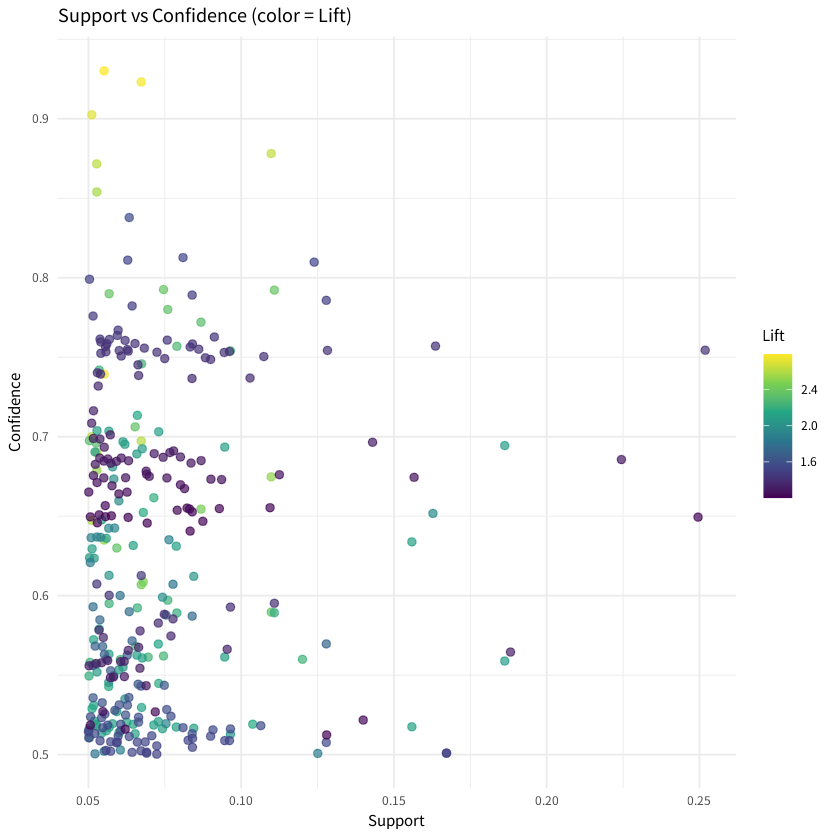

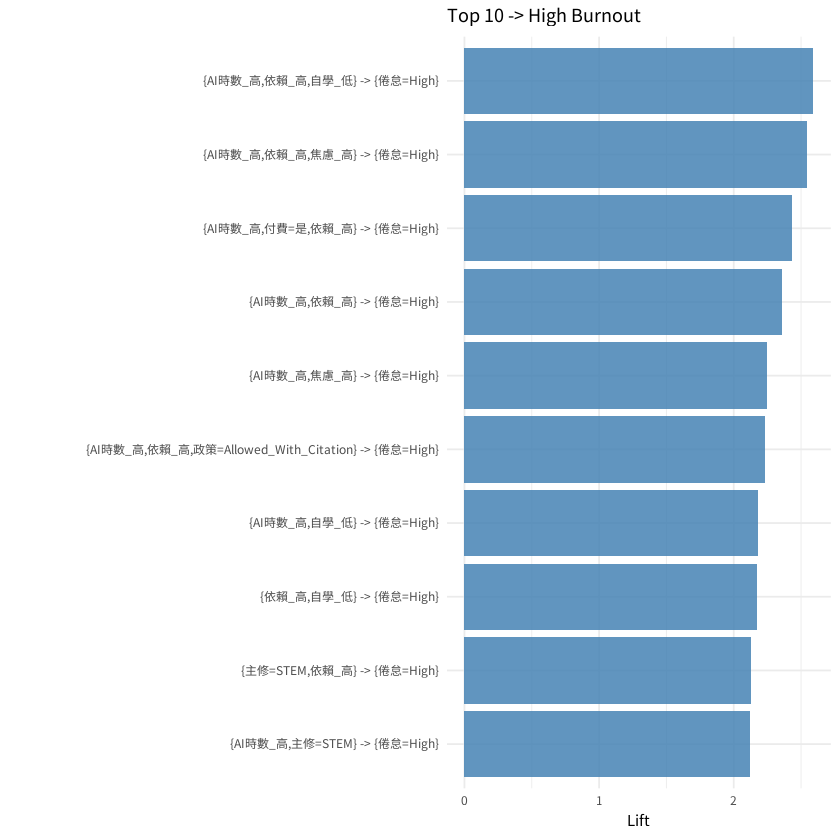


分析完成！耗時 20.8 秒
已將結果打包為 association_rules_output.zip，請從左側 Files 介面下載。


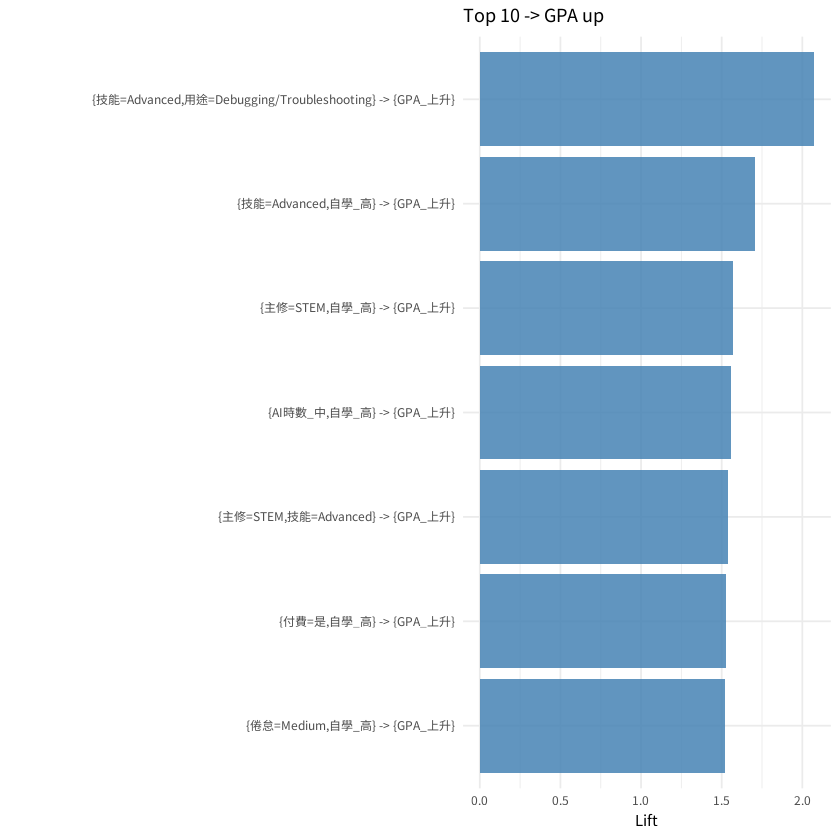

In [25]:
# ── 1. 安裝並載入 R 套件與中文字體設定 ────────────────────────────────
required_pkgs <- c("arules", "ggplot2", "showtext")
for (pkg in required_pkgs) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}
library(arules)
library(ggplot2)
library(showtext)

# 下載並設定 Google 思源黑體 (Noto Sans TC) 以解決圖表中文亂碼
font_add_google("Noto Sans TC", "noto")
showtext_auto()

cat("R 套件與中文字體設定完成\n")

# ── 2. 設定參數與路徑 ──────────────────────────────────
DATA_PATH <- "ai_student_impact_dataset_final.rds"
OUTPUT_DIR <- "outputs/association_rules"

MIN_SUPPORT    <- 0.05
MIN_CONFIDENCE <- 0.5
MIN_LIFT       <- 1.2
TOP_N          <- 20

dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

# ── 3. 函式定義 ────────────────────────────────────────
load_data <- function() {
  df <- readRDS(DATA_PATH)
  df$Year_of_Study[is.na(df$Year_of_Study)] <- "Unknown"
  df
}

bin_numeric <- function(x, labels, q = 3) {
  probs <- seq(0, 1, length.out = q + 1)
  brk <- unique(quantile(x, probs = probs, na.rm = TRUE))
  if (length(brk) < 2) return(factor(rep(labels[1], length(x)), levels = labels))
  n_labels <- length(brk) - 1
  cut(x, breaks = brk, labels = labels[seq_len(n_labels)], include.lowest = TRUE)
}

to_transactions <- function(df) {
  d <- df
  d$AI_Hours    <- bin_numeric(d$Weekly_GenAI_Hours, c("AI時數_低", "AI時數_中", "AI時數_高"))
  d$GPA_Level   <- bin_numeric(d$GPA_Change, c("GPA_下降", "GPA_持平", "GPA_上升"))
  d$Study_Hours <- bin_numeric(d$Traditional_Study_Hours, c("自學_低", "自學_中", "自學_高"))
  d$AI_Dep      <- bin_numeric(d$Perceived_AI_Dependency, c("依賴_低", "依賴_中", "依賴_高"))
  d$Anxiety     <- bin_numeric(d$Anxiety_Level_During_Exams, c("焦慮_低", "焦慮_中", "焦慮_高"))

  trans_list <- vector("list", nrow(d))
  for (i in seq_len(nrow(d))) {
    row <- d[i, ]
    trans_list[[i]] <- c(
      paste0("主修=", row$Major_Category),
      paste0("年級=", row$Year_of_Study),
      paste0("用途=", row$Primary_Use_Case),
      paste0("技能=", row$Prompt_Engineering_Skill),
      paste0("政策=", row$Institutional_Policy),
      paste0("倦怠=", row$Burnout_Risk_Level),
      as.character(row$AI_Hours), as.character(row$GPA_Level),
      as.character(row$Study_Hours), as.character(row$AI_Dep),
      as.character(row$Anxiety),
      if (row$Paid_Subscription == 1) "付費=是" else "付費=否"
    )
  }
  trans_list
}

rules_to_dataframe <- function(rules) {
  lhs_labels <- labels(lhs(rules))
  rhs_labels <- labels(rhs(rules))
  antecedents_str <- vapply(lhs_labels, function(x) paste(x, collapse = ", "), character(1))
  consequents_str <- vapply(rhs_labels, function(x) paste(x, collapse = ", "), character(1))

  q <- quality(rules)

  data.frame(
    antecedents_str = antecedents_str, consequents_str = consequents_str,
    support = q[, "support"], confidence = q[, "confidence"],
    lift = q[, "lift"],
    stringsAsFactors = FALSE
  )
}

write_excel_csv <- function(df, filename) {
  con <- file(filename, open = "w", encoding = "UTF-8")
  cat("\ufeff", file = con, sep = "")
  write.csv(df, con, row.names = FALSE)
  close(con)
}

filter_rules_by_consequent <- function(rules_df, keyword, filename) {
  sub <- rules_df[grepl(keyword, rules_df$consequents_str, fixed = TRUE), ]
  sub <- sub[order(-sub$lift), ]
  write_excel_csv(sub[, c("antecedents_str", "consequents_str", "support", "confidence", "lift")],
                  file.path(OUTPUT_DIR, filename))
  sub
}

cat("準備工作完成，開始分析...\n")

# ── 4. 分析流程 ────────────────────────────────────────
t0 <- proc.time()

# 步驟 1：資料項目化
df <- load_data()
trans_list <- to_transactions(df)
trans <- as(trans_list, "transactions")
cat(sprintf("資料筆數：%s\n", format(nrow(df), big.mark = ",")))

# 步驟 2：Apriori 頻繁項目集
itemsets <- apriori(trans, parameter = list(supp = MIN_SUPPORT, target = "frequent itemsets", minlen = 1))
itemsets_df <- as(itemsets, "data.frame")
itemsets_df <- itemsets_df[order(-itemsets_df$support), ]
write_excel_csv(itemsets_df, file.path(OUTPUT_DIR, "01_frequent_itemsets.csv"))

# 步驟 3：關聯規則
rules <- apriori(trans, parameter = list(supp = MIN_SUPPORT, conf = MIN_CONFIDENCE, target = "rules", minlen = 2))
rules <- subset(rules, lift >= MIN_LIFT)
rules_df <- rules_to_dataframe(rules)
rules_df <- rules_df[order(-rules_df$lift, -rules_df$confidence), ]
write_excel_csv(rules_df, file.path(OUTPUT_DIR, "02_association_rules_all.csv"))

burnout_rules <- filter_rules_by_consequent(rules_df, "倦怠=High", "04_rules_burnout_high.csv")
gpa_rules     <- filter_rules_by_consequent(rules_df, "GPA_上升", "05_rules_gpa_up.csv")

# 步驟 4：視覺化
p1 <- ggplot(rules_df, aes(x = support, y = confidence, color = lift)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_viridis_c(option = "YlOrRd") +
  labs(x = "Support", y = "Confidence", color = "Lift",
       title = "Support vs Confidence (color = Lift)") +
  theme_minimal(base_family = "noto")
ggsave(file.path(OUTPUT_DIR, "03_support_confidence_lift.png"), p1, width = 8, height = 6, dpi = 150)
print(p1)

plot_top <- function(keyword, title, filename) {
  sub <- rules_df[grepl(keyword, rules_df$consequents_str, fixed = TRUE), ]
  sub <- head(sub[order(-sub$lift), ], 10)
  if (nrow(sub) == 0) return(invisible(NULL))
  sub$label <- factor(paste0(sub$antecedents_str, " -> ", sub$consequents_str),
                      levels = rev(paste0(sub$antecedents_str, " -> ", sub$consequents_str)))
  p <- ggplot(sub, aes(x = lift, y = label)) +
    geom_col(fill = "steelblue", alpha = 0.85) +
    labs(x = "Lift", y = NULL, title = title) +
    theme_minimal(base_family = "noto")
  ggsave(file.path(OUTPUT_DIR, filename), p, width = 9, height = 5, dpi = 150)
  print(p)
}

plot_top("倦怠=High", "Top 10 -> High Burnout", "06_top_burnout_rules.png")
plot_top("GPA_上升", "Top 10 -> GPA up", "07_top_gpa_up_rules.png")

# 步驟 5：重點解讀與打包下載
elapsed <- (proc.time() - t0)[["elapsed"]]
cat(sprintf("\n分析完成！耗時 %.1f 秒\n", elapsed))

# 在 R 中打包輸出的檔案為 zip
zip("association_rules_output.zip", files = "outputs")
cat("已將結果打包為 association_rules_output.zip，請從左側 Files 介面下載。\n")

R 套件與中文字體設定完成
準備工作完成，開始分析...


Warning message in `[<-.factor`(`*tmp*`, is.na(df$Year_of_Study), value = "Unknown"):
“invalid factor level, NA generated”


資料筆數：50,000
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
         NA    0.1    1 none FALSE            TRUE       5    0.05      1
 maxlen            target  ext
     10 frequent itemsets TRUE

Algorithmic control:
 filter tree heap memopt load sort verbose
    0.1 TRUE TRUE  FALSE TRUE    2    TRUE

Absolute minimum support count: 2500 

set item appearances ...[0 item(s)] done [0.00s].
set transactions ...[41 item(s), 50000 transaction(s)] done [0.04s].
sorting and recoding items ... [41 item(s)] done [0.01s].
creating transaction tree ... done [0.03s].
checking subsets of size 1 2 3 4 5 done [0.17s].
sorting transactions ... done [0.01s].
writing ... [1439 set(s)] done [0.00s].
creating S4 object  ... done [0.01s].
Apriori

Parameter specification:
 confidence minval smax arem  aval originalSupport maxtime support minlen
        0.5    0.1    1 none FALSE            TRUE       5    0.05      2
 maxlen target  ext
     10

Warning message in viridisLite::viridis(n, alpha, begin, end, direction, option):
“Option 'YlOrRd' does not exist. Defaulting to 'viridis'.”


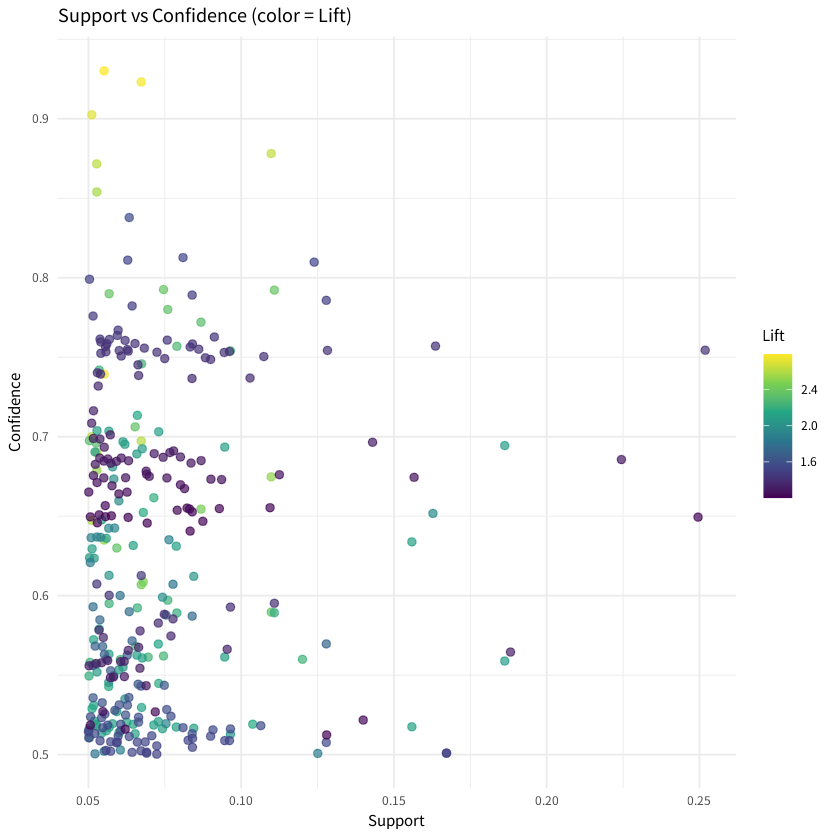

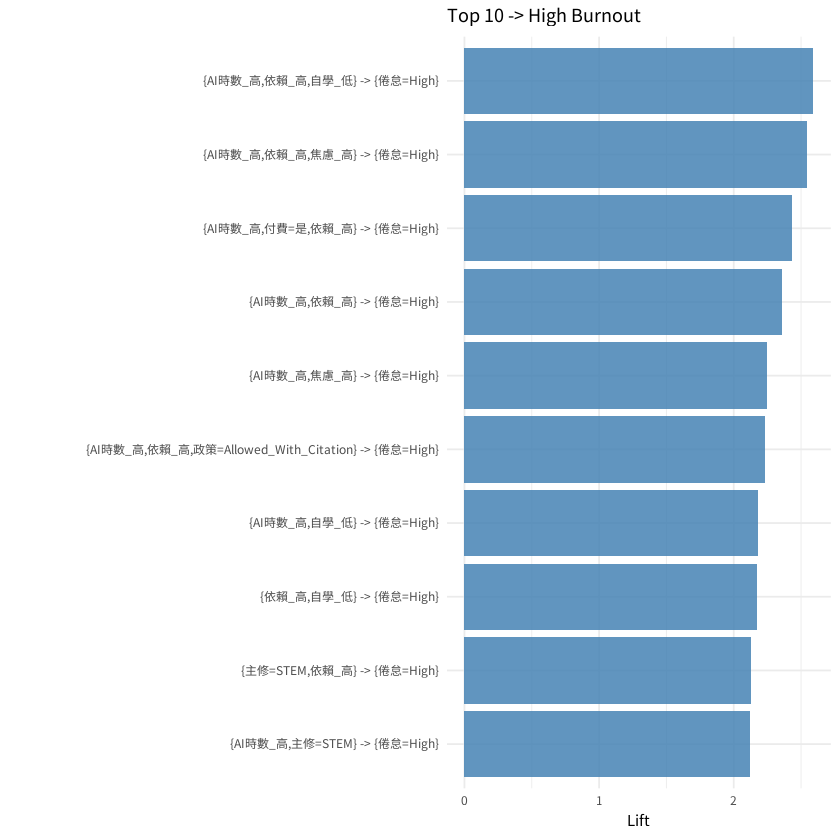


分析完成！耗時 20.7 秒
已將結果打包為 association_rules_output.zip，請從左側 Files 介面下載。


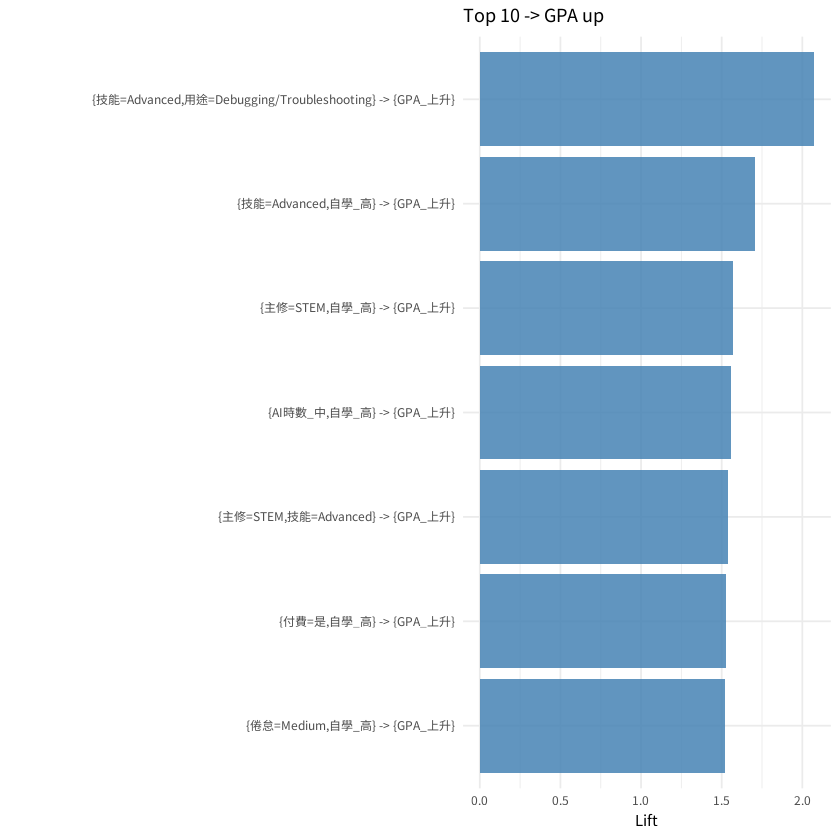

In [26]:
# ── 1. 安裝並載入 R 套件與中文字體設定 ────────────────────────────────
required_pkgs <- c("arules", "ggplot2", "showtext")
for (pkg in required_pkgs) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}
library(arules)
library(ggplot2)
library(showtext)

# 下載並設定 Google 思源黑體 (Noto Sans TC) 以解決圖表中文亂碼
font_add_google("Noto Sans TC", "noto")
showtext_auto()

cat("R 套件與中文字體設定完成\n")

# ── 2. 設定參數與路徑 ──────────────────────────────────
DATA_PATH <- "ai_student_impact_dataset_final.rds"
OUTPUT_DIR <- "outputs/association_rules"

MIN_SUPPORT    <- 0.05
MIN_CONFIDENCE <- 0.5
MIN_LIFT       <- 1.2
TOP_N          <- 20

dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

# ── 3. 函式定義 ────────────────────────────────────────
load_data <- function() {
  df <- readRDS(DATA_PATH)
  df$Year_of_Study[is.na(df$Year_of_Study)] <- "Unknown"
  df
}

bin_numeric <- function(x, labels, q = 3) {
  probs <- seq(0, 1, length.out = q + 1)
  brk <- unique(quantile(x, probs = probs, na.rm = TRUE))
  if (length(brk) < 2) return(factor(rep(labels[1], length(x)), levels = labels))
  n_labels <- length(brk) - 1
  cut(x, breaks = brk, labels = labels[seq_len(n_labels)], include.lowest = TRUE)
}

to_transactions <- function(df) {
  d <- df
  d$AI_Hours    <- bin_numeric(d$Weekly_GenAI_Hours, c("AI時數_低", "AI時數_中", "AI時數_高"))
  d$GPA_Level   <- bin_numeric(d$GPA_Change, c("GPA_下降", "GPA_持平", "GPA_上升"))
  d$Study_Hours <- bin_numeric(d$Traditional_Study_Hours, c("自學_低", "自學_中", "自學_高"))
  d$AI_Dep      <- bin_numeric(d$Perceived_AI_Dependency, c("依賴_低", "依賴_中", "依賴_高"))
  d$Anxiety     <- bin_numeric(d$Anxiety_Level_During_Exams, c("焦慮_低", "焦慮_中", "焦慮_高"))

  trans_list <- vector("list", nrow(d))
  for (i in seq_len(nrow(d))) {
    row <- d[i, ]
    trans_list[[i]] <- c(
      paste0("主修=", row$Major_Category),
      paste0("年級=", row$Year_of_Study),
      paste0("用途=", row$Primary_Use_Case),
      paste0("技能=", row$Prompt_Engineering_Skill),
      paste0("政策=", row$Institutional_Policy),
      paste0("倦怠=", row$Burnout_Risk_Level),
      as.character(row$AI_Hours), as.character(row$GPA_Level),
      as.character(row$Study_Hours), as.character(row$AI_Dep),
      as.character(row$Anxiety),
      if (row$Paid_Subscription == 1) "付費=是" else "付費=否"
    )
  }
  trans_list
}

rules_to_dataframe <- function(rules) {
  lhs_labels <- labels(lhs(rules))
  rhs_labels <- labels(rhs(rules))
  antecedents_str <- vapply(lhs_labels, function(x) paste(x, collapse = ", "), character(1))
  consequents_str <- vapply(rhs_labels, function(x) paste(x, collapse = ", "), character(1))

  q <- quality(rules)

  data.frame(
    antecedents_str = antecedents_str, consequents_str = consequents_str,
    support = q[, "support"], confidence = q[, "confidence"],
    lift = q[, "lift"],
    stringsAsFactors = FALSE
  )
}

write_excel_csv <- function(df, filename) {
  con <- file(filename, open = "w", encoding = "UTF-8")
  cat("\ufeff", file = con, sep = "") # 寫入 UTF-8 BOM 標頭，強迫 Excel 用 UTF-8 開啟
  write.csv(df, con, row.names = FALSE)
  close(con)
}

filter_rules_by_consequent <- function(rules_df, keyword, filename) {
  sub <- rules_df[grepl(keyword, rules_df$consequents_str, fixed = TRUE), ]
  sub <- sub[order(-sub$lift), ]
  write_excel_csv(sub[, c("antecedents_str", "consequents_str", "support", "confidence", "lift")],
                  file.path(OUTPUT_DIR, filename))
  sub
}

cat("準備工作完成，開始分析...\n")

# ── 4. 分析流程 ────────────────────────────────────────
t0 <- proc.time()

# 步驟 1：資料項目化
df <- load_data()
trans_list <- to_transactions(df)
trans <- as(trans_list, "transactions")
cat(sprintf("資料筆數：%s\n", format(nrow(df), big.mark = ",")))

# 步驟 2：Apriori 頻繁項目集
itemsets <- apriori(trans, parameter = list(supp = MIN_SUPPORT, target = "frequent itemsets", minlen = 1))
itemsets_df <- as(itemsets, "data.frame")
itemsets_df <- itemsets_df[order(-itemsets_df$support), ]
write_excel_csv(itemsets_df, file.path(OUTPUT_DIR, "01_frequent_itemsets.csv"))

# 步驟 3：關聯規則
rules <- apriori(trans, parameter = list(supp = MIN_SUPPORT, conf = MIN_CONFIDENCE, target = "rules", minlen = 2))
rules <- subset(rules, lift >= MIN_LIFT)
rules_df <- rules_to_dataframe(rules)
rules_df <- rules_df[order(-rules_df$lift, -rules_df$confidence), ]
write_excel_csv(rules_df, file.path(OUTPUT_DIR, "02_association_rules_all.csv"))

burnout_rules <- filter_rules_by_consequent(rules_df, "倦怠=High", "04_rules_burnout_high.csv")
gpa_rules     <- filter_rules_by_consequent(rules_df, "GPA_上升", "05_rules_gpa_up.csv")

# 步驟 4：視覺化
p1 <- ggplot(rules_df, aes(x = support, y = confidence, color = lift)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_color_viridis_c(option = "YlOrRd") +
  labs(x = "Support", y = "Confidence", color = "Lift",
       title = "Support vs Confidence (color = Lift)") +
  theme_minimal(base_family = "noto")
ggsave(file.path(OUTPUT_DIR, "03_support_confidence_lift.png"), p1, width = 8, height = 6, dpi = 150)
print(p1)

plot_top <- function(keyword, title, filename) {
  sub <- rules_df[grepl(keyword, rules_df$consequents_str, fixed = TRUE), ]
  sub <- head(sub[order(-sub$lift), ], 10)
  if (nrow(sub) == 0) return(invisible(NULL))
  sub$label <- factor(paste0(sub$antecedents_str, " -> ", sub$consequents_str),
                      levels = rev(paste0(sub$antecedents_str, " -> ", sub$consequents_str)))
  p <- ggplot(sub, aes(x = lift, y = label)) +
    geom_col(fill = "steelblue", alpha = 0.85) +
    labs(x = "Lift", y = NULL, title = title) +
    theme_minimal(base_family = "noto")
  ggsave(file.path(OUTPUT_DIR, filename), p, width = 9, height = 5, dpi = 150)
  print(p)
}

plot_top("倦怠=High", "Top 10 -> High Burnout", "06_top_burnout_rules.png")
plot_top("GPA_上升", "Top 10 -> GPA up", "07_top_gpa_up_rules.png")

# 步驟 5：重點解讀與打包下載
elapsed <- (proc.time() - t0)[["elapsed"]]
cat(sprintf("\n分析完成！耗時 %.1f 秒\n", elapsed))

# 在 R 中打包輸出的檔案為 zip
zip("association_rules_output.zip", files = "outputs")
cat("已將結果打包為 association_rules_output.zip，請從左側 Files 介面下載。\n")

### Kmeans

In [27]:
# ── 1. 安裝並載入必備 R 套件與中文字體設定 ────────────────────────────────
required_pkgs <- c("dplyr", "tidyr", "ggplot2", "cluster", "showtext", "patchwork")
for (pkg in required_pkgs) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}

library(dplyr)
library(tidyr)
library(ggplot2)
library(cluster)
library(showtext)
library(patchwork) # 用於合併圖表

# 設定 Google 思源黑體 (Noto Sans TC) 以解決圖表中文亂碼
font_add_google("Noto Sans TC", "noto")
showtext_auto()

cat("R 套件與中文字體設定完成\n")

# ── 2. 設定參數與路徑 ──────────────────────────────────
DATA_PATH <- "ai_student_impact_dataset_final.rds"
OUTPUT_DIR <- "outputs/kmeans"
dir.create(OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)

RANDOM_STATE <- 42
K_RANGE <- 2:8
K_SELECT_SAMPLE <- 10000

CLUSTER_FEATURES <- c(
  "Weekly_GenAI_Hours", "Traditional_Study_Hours", "AI_Time_Ratio",
  "Perceived_AI_Dependency", "Tool_Diversity", "Skill_Retention_Score",
  "Anxiety_Level_During_Exams"
)

PROFILE_FEATURES <- c(
  CLUSTER_FEATURES, "Pre_Semester_GPA", "GPA_Change", "Post_Semester_GPA"
)

# ── 3. 函式定義 ────────────────────────────────────────

write_excel_csv <- function(df, filename) {
  con <- file(filename, open = "w", encoding = "UTF-8")
  cat("\ufeff", file = con, sep = "")
  write.csv(df, con, row.names = FALSE)
  close(con)
}

# ── 4. 分析主流程 ────────────────────────────────────────
t0 <- proc.time()

cat("K-Means 聚類分析啟動...\n\n")

# 讀取資料
df <- readRDS(DATA_PATH)
df$Year_of_Study[is.na(df$Year_of_Study)] <- "Unknown"
cat(sprintf("資料筆數：%s\n", format(nrow(df), big.mark = ",")))

# 標準化聚類特徵
X_raw <- df[, CLUSTER_FEATURES]
X_scaled <- scale(X_raw)

# 步驟 1：選擇最佳 K (Elbow + Silhouette)
cat(paste0("\n", strrep("=", 60), "\n步驟 1：選擇 k（Elbow + Silhouette）\n", strrep("=", 60), "\n"))

set.seed(RANDOM_STATE)
# 為了避免大樣本 Silhouette 算太久，抽樣計算
sample_size <- min(K_SELECT_SAMPLE, nrow(X_scaled))
sample_idx <- sample(seq_len(nrow(X_scaled)), sample_size)
X_sub <- X_scaled[sample_idx, ]
dist_sub <- dist(X_sub)

inertias <- numeric(length(K_RANGE))
silhouettes <- numeric(length(K_RANGE))

for (i in seq_along(K_RANGE)) {
  k <- K_RANGE[i]
  # 計算全樣本 Inertia
  km <- kmeans(X_scaled, centers = k, nstart = 5, iter.max = 50)
  inertias[i] <- km$tot.withinss

  # 計算子樣本 Silhouette
  km_sub <- kmeans(X_sub, centers = k, nstart = 5, iter.max = 50)
  sil <- silhouette(km_sub$cluster, dist_sub)
  silhouettes[i] <- mean(sil[, 3])
}

best_k <- K_RANGE[which.max(silhouettes)]

for (i in seq_along(K_RANGE)) {
  mark <- ifelse(K_RANGE[i] == best_k, " <-- best", "")
  cat(sprintf("  k=%d: inertia=%.1f, silhouette=%.3f%s\n", K_RANGE[i], inertias[i], silhouettes[i], mark))
}

# 繪製 K 選擇圖
eval_df <- data.frame(k = K_RANGE, Inertia = inertias, Silhouette = silhouettes)
p_elbow <- ggplot(eval_df, aes(x = k, y = Inertia)) +
  geom_line(color = "steelblue") + geom_point(color = "steelblue", size = 3) +
  theme_minimal(base_family = "noto") + labs(title = "Elbow Method")

p_sil <- ggplot(eval_df, aes(x = k, y = Silhouette)) +
  geom_line(color = "coral") + geom_point(color = "coral", size = 3) +
  geom_vline(xintercept = best_k, linetype = "dashed", color = "gray") +
  theme_minimal(base_family = "noto") + labs(title = "Silhouette Score")

ggsave(file.path(OUTPUT_DIR, "01_k_selection.png"), p_elbow + p_sil, width = 11, height = 4, dpi = 150)


# 步驟 2：正式 K-Means 聚類
cat(paste0("\n", strrep("=", 60), "\n步驟 2：K-Means 聚類（k = ", best_k, "）\n", strrep("=", 60), "\n"))
set.seed(RANDOM_STATE)
km_final <- kmeans(X_scaled, centers = best_k, nstart = 5, iter.max = 50)
df$Cluster <- km_final$cluster

# 群組輪廓
profile <- df %>%
  group_by(Cluster) %>%
  summarise(across(all_of(PROFILE_FEATURES), ~ round(mean(.x, na.rm = TRUE), 3)))

write_excel_csv(profile, file.path(OUTPUT_DIR, "01_cluster_profile.csv"))
cat("\n各群平均特徵：\n")
print(profile)

# 類別分布表
cat("\n各群主修分布：\n")
major_dist <- prop.table(table(df$Cluster, df$Major_Category), margin = 1) %>% round(3)
print(major_dist)

cat("\n各群倦怠風險分布：\n")
burnout_dist <- prop.table(table(df$Cluster, df$Burnout_Risk_Level), margin = 1) %>% round(3)
print(burnout_dist)
write_excel_csv(as.data.frame(unclass(burnout_dist)), file.path(OUTPUT_DIR, "02_burnout_distribution.csv"))

# 群組命名 (依 AI 時數高低)
ai_median <- median(profile$Weekly_GenAI_Hours)
cluster_names <- sapply(profile$Cluster, function(c) {
  val <- profile$Weekly_GenAI_Hours[profile$Cluster == c]
  if (val >= ai_median) paste0("Cluster_", c, "_AI重度") else paste0("Cluster_", c, "_傳統學習")
})
names(cluster_names) <- profile$Cluster
df$Cluster_Label <- cluster_names[as.character(df$Cluster)]

out_cols <- c("Cluster", "Cluster_Label", PROFILE_FEATURES, "Major_Category", "Burnout_Risk_Level", "Institutional_Policy")
write_excel_csv(df[, out_cols], file.path(OUTPUT_DIR, "03_labeled_dataset.csv"))


# 步驟 3：視覺化
cat(paste0("\n", strrep("=", 60), "\n步驟 3：視覺化\n", strrep("=", 60), "\n"))

# 3-1: PCA 2D 散佈圖
pca_res <- prcomp(X_scaled)
pca_df <- data.frame(
  PC1 = pca_res$x[, 1],
  PC2 = pca_res$x[, 2],
  Cluster = as.factor(df$Cluster)
)
# 如果資料太大，抽樣畫圖
pca_df_sub <- pca_df[sample_idx, ]

var_exp <- round(pca_res$sdev^2 / sum(pca_res$sdev^2) * 100, 1)

p_pca <- ggplot(pca_df_sub, aes(x = PC1, y = PC2, color = Cluster)) +
  geom_point(alpha = 0.5, size = 1.5) +
  scale_color_brewer(palette = "Set1") +
  theme_minimal(base_family = "noto") +
  labs(title = "K-Means 聚類 — PCA 2D 視覺化",
       x = sprintf("PC1 (%.1f%%)", var_exp[1]),
       y = sprintf("PC2 (%.1f%%)", var_exp[2]))
ggsave(file.path(OUTPUT_DIR, "02_pca_clusters.png"), p_pca, width = 8, height = 6, dpi = 150)


# 3-2: 各群平均特徵熱圖
profile_scaled <- profile[, c("Cluster", CLUSTER_FEATURES)] %>%
  mutate(across(-Cluster, ~ (.x - min(.x)) / (max(.x) - min(.x) + 1e-9))) %>%
  pivot_longer(cols = -Cluster, names_to = "Feature", values_to = "Value")

p_heat <- ggplot(profile_scaled, aes(x = as.factor(Cluster), y = Feature, fill = Value)) +
  geom_tile(color = "white") +
  scale_fill_viridis_c(option = "YlOrRd") +
  theme_minimal(base_family = "noto") +
  labs(title = "各群平均特徵 (標準化 0-1)", x = "Cluster", y = "")
ggsave(file.path(OUTPUT_DIR, "03_cluster_heatmap.png"), p_heat, width = 8, height = 5, dpi = 150)


# 3-3: 倦怠風險分布長條圖
df$Burnout_Risk_Level <- factor(df$Burnout_Risk_Level, levels = c("High", "Medium", "Low"))
p_burnout <- ggplot(df, aes(x = as.factor(Cluster), fill = Burnout_Risk_Level)) +
  geom_bar(position = "fill") +
  scale_fill_manual(values = c("High" = "#e74c3c", "Medium" = "#f1c40f", "Low" = "#2ecc71")) +
  scale_y_continuous(labels = scales::percent_format()) +
  theme_minimal(base_family = "noto") +
  labs(title = "各群倦怠風險分布", x = "Cluster", y = "比例", fill = "Burnout")
ggsave(file.path(OUTPUT_DIR, "04_burnout_by_cluster.png"), p_burnout, width = 8, height = 5, dpi = 150)


# 步驟 4：解讀
cat(paste0("\n", strrep("=", 60), "\n群組解讀\n", strrep("=", 60), "\n"))
for (c in sort(unique(df$Cluster))) {
  sub_df <- df[df$Cluster == c, ]
  c_name <- cluster_names[as.character(c)]
  cat(sprintf("\n  [%s] n=%s\n", c_name, format(nrow(sub_df), big.mark = ",")))
  cat(sprintf("    AI 時數=%.1f hr/週\n", profile$Weekly_GenAI_Hours[profile$Cluster == c]))
  cat(sprintf("    自學時數=%.1f hr/週\n", profile$Traditional_Study_Hours[profile$Cluster == c]))
  cat(sprintf("    GPA 變化=%+.3f\n", profile$GPA_Change[profile$Cluster == c]))
  high_pct <- mean(sub_df$Burnout_Risk_Level == "High", na.rm = TRUE) * 100
  cat(sprintf("    High Burnout=%.1f%%\n", high_pct))
}

elapsed <- (proc.time() - t0)[["elapsed"]]
cat(sprintf("\n分析完成！耗時 %.1f 秒\n", elapsed))
cat("所有結果已輸出至 outputs/kmeans 資料夾\n")

R 套件與中文字體設定完成
K-Means 聚類分析啟動...



Warning message in `[<-.factor`(`*tmp*`, is.na(df$Year_of_Study), value = "Unknown"):
“invalid factor level, NA generated”


資料筆數：50,000

步驟 1：選擇 k（Elbow + Silhouette）


Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2500000)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2500000)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2500000)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2500000)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 2500000)”


  k=2: inertia=261534.8, silhouette=0.254 <-- best
  k=3: inertia=232249.6, silhouette=0.158
  k=4: inertia=210809.8, silhouette=0.147
  k=5: inertia=195995.8, silhouette=0.148
  k=6: inertia=185232.6, silhouette=0.134
  k=7: inertia=176405.5, silhouette=0.132
  k=8: inertia=169651.3, silhouette=0.130

步驟 2：K-Means 聚類（k = 2）

各群平均特徵：
# A tibble: 2 × 11
  Cluster Weekly_GenAI_Hours Traditional_Study_Hours AI_Time_Ratio
    <int>              <dbl>                   <dbl>         <dbl>
1       1               4.33                   12.5          0.246
2       2              17.2                     8.43         0.666
# ℹ 7 more variables: Perceived_AI_Dependency <dbl>, Tool_Diversity <dbl>,
#   Skill_Retention_Score <dbl>, Anxiety_Level_During_Exams <dbl>,
#   Pre_Semester_GPA <dbl>, GPA_Change <dbl>, Post_Semester_GPA <dbl>

各群主修分布：
   
     Arts Business Humanities Medical  STEM
  1 0.126    0.252      0.219   0.136 0.267
  2 0.103    0.248      0.159   0.116 0.375

各群倦怠風險分布：
   
     

Warning message in viridisLite::viridis(n, alpha, begin, end, direction, option):
“Option 'YlOrRd' does not exist. Defaulting to 'viridis'.”



群組解讀

  [Cluster_1_傳統學習] n=34,067
    AI 時數=4.3 hr/週
    自學時數=12.5 hr/週
    GPA 變化=+0.219
    High Burnout=13.7%

  [Cluster_2_AI重度] n=15,933
    AI 時數=17.2 hr/週
    自學時數=8.4 hr/週
    GPA 變化=+0.170
    High Burnout=49.2%

分析完成！耗時 19.8 秒
所有結果已輸出至 outputs/kmeans 資料夾


In [28]:
system("zip -r outputs.zip /content/outputs")